In [ ]:
!pip install -q timm seaborn scikit-learn

import os
import json
import random
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

import torchvision
from torchvision import transforms
from torchvision.datasets import Caltech101

import timm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# SEED
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ============================================================
# DEVICE
# ============================================================

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print("DEVICE:", DEVICE)

# ============================================================
# TRANSFORMS
# ============================================================

BATCH_SIZE = 32
IMAGE_SIZE = 224

# ============================================================
# SAVE DIRECTORY
# ============================================================

SAVE_DIR = "/content/drive/MyDrive/VKR additional experiments"

os.makedirs(SAVE_DIR, exist_ok=True)

print("SAVE DIR:", SAVE_DIR)

DEVICE: cuda
SAVE DIR: /content/drive/MyDrive/VKR additional experiments


In [ ]:
train_transform = transforms.Compose([

    transforms.Lambda(
        lambda img: img.convert('RGB')
    ),

    transforms.Resize((256, 256)),

    transforms.RandomCrop(224),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([

    transforms.Lambda(
        lambda img: img.convert('RGB')
    ),

    transforms.Resize((256, 256)),

    transforms.RandomCrop(224),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
# ============================================================
# IMPORTS
# ============================================================

import os
import json
import random
import numpy as np
import pandas as pd

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

from torchvision import transforms
from torchvision import datasets

import timm
# ============================================================
# DATASET
# ============================================================

DATASET_PATH = (
    '/content/drive/MyDrive/caltech101/caltech101/101_ObjectCategories'
)

# ============================================================
# IMAGEFOLDER DATASET
# ============================================================

full_dataset = datasets.ImageFolder(

    root=DATASET_PATH,

    transform=train_transform
)

print('CLASSES:', len(full_dataset.classes))
print('IMAGES:', len(full_dataset))

print(full_dataset.classes)

# ============================================================
# SPLIT
# ============================================================

train_size = int(0.8 * len(full_dataset))

val_size = len(full_dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(

    full_dataset,

    [train_size, val_size]
)

# ============================================================
# VALIDATION TRANSFORM
# ============================================================

val_dataset.dataset.transform = val_transform

# ============================================================
# DATALOADERS
# ============================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=2,

    pin_memory=True
)

val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=True
)

print('TRAIN:', len(train_dataset))
print('VAL:', len(val_dataset))

CLASSES: 101
IMAGES: 8677
['Faces', 'Faces_easy', 'Leopards', 'Motorbikes', 'accordion', 'airplanes', 'anchor', 'ant', 'barrel', 'bass', 'beaver', 'binocular', 'bonsai', 'brain', 'brontosaurus', 'buddha', 'butterfly', 'camera', 'cannon', 'car_side', 'ceiling_fan', 'cellphone', 'chair', 'chandelier', 'cougar_body', 'cougar_face', 'crab', 'crayfish', 'crocodile', 'crocodile_head', 'cup', 'dalmatian', 'dollar_bill', 'dolphin', 'dragonfly', 'electric_guitar', 'elephant', 'emu', 'euphonium', 'ewer', 'ferry', 'flamingo', 'flamingo_head', 'garfield', 'gerenuk', 'gramophone', 'grand_piano', 'hawksbill', 'headphone', 'hedgehog', 'helicopter', 'ibis', 'inline_skate', 'joshua_tree', 'kangaroo', 'ketch', 'lamp', 'laptop', 'llama', 'lobster', 'lotus', 'mandolin', 'mayfly', 'menorah', 'metronome', 'minaret', 'nautilus', 'octopus', 'okapi', 'pagoda', 'panda', 'pigeon', 'pizza', 'platypus', 'pyramid', 'revolver', 'rhino', 'rooster', 'saxophone', 'schooner', 'scissors', 'scorpion', 'sea_horse', 'snoopy

In [ ]:
# ============================================================
# LEGENDRE KAN
# ============================================================

class LegendreKANLayer(nn.Module):

    def __init__(self, input_dim, output_dim, degree=6):

        super().__init__()

        self.degree = degree

        self.coeffs = nn.Parameter(
            torch.randn(
                input_dim,
                output_dim,
                degree + 1
            ) * 0.01
        )

    def compute_legendre(self, x):

        P = [torch.ones_like(x)]

        if self.degree >= 1:
            P.append(x)

        for n in range(2, self.degree + 1):

            pn = (
                ((2 * n - 1) * x * P[n - 1])
                - ((n - 1) * P[n - 2])
            ) / n

            P.append(pn)

        return torch.stack(P, dim=-1)

    def forward(self, x):

        x = torch.tanh(x)

        polys = self.compute_legendre(x)

        out = torch.einsum(
            'bid,iod->bo',
            polys,
            self.coeffs
        )

        return out

In [ ]:
# ============================================================
# CHEBYSHEV KAN
# ============================================================

class ChebyshevKANLayer(nn.Module):

    def __init__(self, input_dim, output_dim, degree=8):

        super().__init__()

        self.degree = degree

        self.coeffs = nn.Parameter(
            torch.randn(
                input_dim,
                output_dim,
                degree + 1
            ) * 0.01
        )

    def compute_chebyshev(self, x):

        T = [torch.ones_like(x), x]

        for n in range(2, self.degree + 1):

            tn = 2 * x * T[n - 1] - T[n - 2]

            T.append(tn)

        return torch.stack(T, dim=-1)

    def forward(self, x):

        x = torch.tanh(x)

        polys = self.compute_chebyshev(x)

        out = torch.einsum(
            'bid,iod->bo',
            polys,
            self.coeffs
        )

        return out


In [ ]:
# ============================================================
# FOURIER KAN
# ============================================================

class FourierKANLayer(nn.Module):

    def __init__(self, input_dim, output_dim, n_freq=8):

        super().__init__()

        self.n_freq = n_freq

        self.a = nn.Parameter(
            torch.randn(
                input_dim,
                output_dim,
                n_freq
            ) * 0.01
        )

        self.b = nn.Parameter(
            torch.randn(
                input_dim,
                output_dim,
                n_freq
            ) * 0.01
        )

        self.bias = nn.Parameter(
            torch.zeros(output_dim)
        )

    def forward(self, x):

        x = torch.tanh(x)

        out = 0

        for k in range(self.n_freq):

            out += torch.einsum(
                'bi,io->bo',
                torch.cos((k + 1) * x),
                self.a[:, :, k]
            )

            out += torch.einsum(
                'bi,io->bo',
                torch.sin((k + 1) * x),
                self.b[:, :, k]
            )

        out += self.bias

        return out


In [ ]:
# ============================================================
# HYBRID POLY KAN
# ============================================================

class HybridPolyKAN(nn.Module):

    def __init__(self, input_dim, output_dim):

        super().__init__()

        self.legendre = LegendreKANLayer(
            input_dim,
            output_dim
        )

        self.chebyshev = ChebyshevKANLayer(
            input_dim,
            output_dim
        )

        self.fourier = FourierKANLayer(
            input_dim,
            output_dim
        )

        self.alpha = nn.Parameter(
            torch.tensor(0.33)
        )

        self.beta = nn.Parameter(
            torch.tensor(0.33)
        )

        self.gamma = nn.Parameter(
            torch.tensor(0.34)
        )

    def forward(self, x):

        out = (

            self.alpha * self.legendre(x)

            + self.beta * self.chebyshev(x)

            + self.gamma * self.fourier(x)
        )

        return out

In [ ]:
# ============================================================
# FULL MODEL
# ============================================================

class ResNetHybridKAN(nn.Module):

    def __init__(self, num_classes=102):

        super().__init__()

        self.backbone = timm.create_model(
            'resnet50',
            pretrained=True,
            num_classes=0,
            global_pool='avg'
        )

        in_features = self.backbone.num_features

        self.classifier = HybridPolyKAN(
            in_features,
            num_classes
        )

    def forward(self, x):

        x = self.backbone(x)

        x = self.classifier(x)

        return x

In [ ]:
# ============================================================
# METRICS
# ============================================================

@torch.no_grad()
def evaluate(model, loader, criterion):

    model.eval()

    losses = []

    preds_all = []
    targets_all = []

    for images, targets in loader:

        images = images.to(DEVICE)
        targets = targets.to(DEVICE)

        outputs = model(images)

        loss = criterion(outputs, targets)

        losses.append(loss.item())

        preds = outputs.argmax(dim=1)

        preds_all.extend(preds.cpu().numpy())
        targets_all.extend(targets.cpu().numpy())

    accuracy = accuracy_score(targets_all, preds_all)

    precision = precision_score(
        targets_all,
        preds_all,
        average='macro',
        zero_division=0
    )

    recall = recall_score(
        targets_all,
        preds_all,
        average='macro',
        zero_division=0
    )

    f1 = f1_score(
        targets_all,
        preds_all,
        average='macro',
        zero_division=0
    )

    return {
        'loss': np.mean(losses),
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }



In [ ]:
# ============================================================
# EARLY STOPPING
# ============================================================

class EarlyStopping:

    def __init__(self, patience=8):

        self.patience = patience

        self.best_loss = float('inf')

        self.counter = 0

        self.stop = False

    def __call__(self, val_loss):

        if val_loss < self.best_loss:

            self.best_loss = val_loss

            self.counter = 0

        else:

            self.counter += 1

        if self.counter >= self.patience:

            self.stop = True


In [ ]:
# ============================================================
# MODEL
# ============================================================

model = ResNetHybridKAN().to(DEVICE)

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20
)

early_stopping = EarlyStopping(
    patience=8
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

In [ ]:
from torch.cuda.amp import autocast, GradScaler
# ============================================================
# TRAINING
# ============================================================

model_name = 'ResNet50_HybridKAN'

checkpoint_path = os.path.join(SAVE_DIR, f'{model_name}_checkpoint.pth')

history = []
best_acc = 0.0
start_epoch = 0

# ============================================================
# OPTIONAL RESUME (если файл есть)
# ============================================================

if os.path.exists(checkpoint_path):

    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)

    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

    history = checkpoint['history']
    best_acc = checkpoint['best_acc']
    start_epoch = checkpoint['epoch'] + 1

    print(f"RESUMED FROM EPOCH: {start_epoch}")
    print(f"BEST ACC: {best_acc:.4f}")

# ============================================================
# TRAIN LOOP
# ============================================================
scaler = GradScaler()
for epoch in range(start_epoch, 1000):

    model.train()

    loop = tqdm(train_loader)

    for images, targets in loop:

        images = images.to(DEVICE)
        targets = targets.to(DEVICE)

        optimizer.zero_grad()

        with autocast():

            outputs = model(images)
            loss = criterion(outputs, targets)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        scaler.step(optimizer)
        scaler.update()

        optimizer.zero_grad()

        loop.set_description(f'Epoch {epoch+1}')
        loop.set_postfix(loss=loss.item())

    scheduler.step()

    # ========================================================
    # VALIDATION
    # ========================================================

    train_metrics = evaluate(model, train_loader, criterion)
    val_metrics = evaluate(model, val_loader, criterion)

    result = {
        'epoch': epoch + 1,
        'train_loss': float(train_metrics['loss']),
        'val_loss': float(val_metrics['loss']),
        'train_acc': float(train_metrics['accuracy']),
        'val_acc': float(val_metrics['accuracy']),
        'precision': float(val_metrics['precision']),
        'recall': float(val_metrics['recall']),
        'f1': float(val_metrics['f1'])
    }

    history.append(result)
    print(result)

    # ========================================================
    # SAVE CHECKPOINT (BEST ONLY)
    # ========================================================

    if val_metrics['accuracy'] > best_acc:

        best_acc = val_metrics['accuracy']

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_acc': best_acc,
            'history': history
        }, checkpoint_path)

        print(f'CHECKPOINT SAVED: {best_acc:.4f}')

    # ========================================================
    # EARLY STOPPING
    # ========================================================

    early_stopping(val_metrics['loss'])

    if early_stopping.stop:
        print('EARLY STOPPING')
        break

# ============================================================
# SAVE CSV HISTORY
# ============================================================

history_df = pd.DataFrame(history)

history_df.to_csv(
    os.path.join(SAVE_DIR, f'{model_name}_history.csv'),
    index=False
)

print('TRAINING FINISHED')

/tmp/ipykernel_2899/1776483267.py:36: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/grad_scaler.py:31: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  super().__init__(
  0%|          | 0/217 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_2899/1776483267.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(
Epoch 1

{'epoch': 1, 'train_loss': 1.3254777703966414, 'val_loss': 1.4079418832605535, 'train_acc': 0.8712001152571676, 'val_acc': 0.8519585253456221, 'precision': 0.7849854346711491, 'recall': 0.7459688871194434, 'f1': 0.7251574518346143}
CHECKPOINT SAVED: 0.8520


  0%|          | 0/217 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_2899/1776483267.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(
Epoch 2: 100%|██████████| 217/217 [1:28:35<00:00, 24.50s/it, loss=1.12]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'epoch': 2, 'train_loss': 1.0200663678657074, 'val_loss': 1.1075166171247308, 'train_acc': 0.9537530615185131, 'val_acc': 0.9262672811059908, 'precision': 0.9074725760566837, 'recall': 0.8879193821079511, 'f1': 0.8757679825352879}
CHECKPOINT SAVED: 0.9263


  0%|          | 0/217 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_2899/1776483267.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(
Epoch 3: 100%|██████████| 217/217 [1:29:11<00:00, 24.66s/it, loss=0.998]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'epoch': 3, 'train_loss': 0.9693162597818858, 'val_loss': 1.0906384229660033, 'train_acc': 0.9755078518945397, 'val_acc': 0.9389400921658986, 'precision': 0.9174722210660651, 'recall': 0.9093430197778638, 'f1': 0.8985969093083989}
CHECKPOINT SAVED: 0.9389


  0%|          | 0/217 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_2899/1776483267.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(
Epoch 4: 100%|██████████| 217/217 [1:29:07<00:00, 24.65s/it, loss=0.946]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'epoch': 4, 'train_loss': 0.9170454765245113, 'val_loss': 1.0428174972534179, 'train_acc': 0.9866013542717188, 'val_acc': 0.9487327188940092, 'precision': 0.9238552463140978, 'recall': 0.9219820135085243, 'f1': 0.9097717863033928}
CHECKPOINT SAVED: 0.9487


  0%|          | 0/217 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_2899/1776483267.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(
Epoch 5: 100%|██████████| 217/217 [1:29:12<00:00, 24.66s/it, loss=0.879]


FileNotFoundError: Caught FileNotFoundError in DataLoader worker process 1.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 52, in fetch
    data = self.dataset.__getitems__(possibly_batched_index)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataset.py", line 443, in __getitems__
    return [self.dataset[self.indices[idx]] for idx in indices]
            ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torchvision/datasets/folder.py", line 245, in __getitem__
    sample = self.loader(path)
             ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torchvision/dataset

Дообучение

In [ ]:
checkpoint_path = os.path.join(
    SAVE_DIR,
    'ResNet50_HybridKAN_checkpoint.pth'
)

checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint['model_state_dict']
)

optimizer.load_state_dict(
    checkpoint['optimizer_state_dict']
)

scheduler.load_state_dict(
    checkpoint['scheduler_state_dict']
)

history = checkpoint['history']

best_acc = checkpoint['best_acc']

start_epoch = checkpoint['epoch'] + 1

print(f'RESUMED FROM EPOCH: {start_epoch}')
print(f'BEST ACC: {best_acc:.4f}')

RESUMED FROM EPOCH: 4
BEST ACC: 0.9487


In [ ]:
scaler = torch.amp.GradScaler(
    'cuda',
    enabled=torch.cuda.is_available()
)

for epoch in range(start_epoch, 1000):

    model.train()

    loop = tqdm(train_loader)

    for images, targets in loop:

        images = images.to(DEVICE)
        targets = targets.to(DEVICE)

        optimizer.zero_grad()

        with torch.amp.autocast(
            device_type='cuda',
            enabled=torch.cuda.is_available()
        ):

            outputs = model(images)

            loss = criterion(outputs, targets)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        scaler.step(optimizer)

        scaler.update()

        loop.set_description(f'Epoch {epoch+1}')

        loop.set_postfix(loss=loss.item())

    scheduler.step()

    train_metrics = evaluate(
        model,
        train_loader,
        criterion
    )

    val_metrics = evaluate(
        model,
        val_loader,
        criterion
    )

    result = {

        'epoch': epoch + 1,

        'train_loss': float(train_metrics['loss']),
        'val_loss': float(val_metrics['loss']),

        'train_acc': float(train_metrics['accuracy']),
        'val_acc': float(val_metrics['accuracy']),

        'precision': float(val_metrics['precision']),
        'recall': float(val_metrics['recall']),
        'f1': float(val_metrics['f1'])
    }

    history.append(result)

    print(result)

    # SAVE BEST CHECKPOINT

    if val_metrics['accuracy'] > best_acc:

        best_acc = val_metrics['accuracy']

        torch.save({

            'epoch': epoch,

            'model_state_dict': model.state_dict(),

            'optimizer_state_dict': optimizer.state_dict(),

            'scheduler_state_dict': scheduler.state_dict(),

            'best_acc': best_acc,

            'history': history

        }, checkpoint_path)

        print(f'CHECKPOINT SAVED: {best_acc:.4f}')

Epoch 5: 100%|██████████| 217/217 [44:40<00:00, 12.35s/it, loss=0.94]


{'epoch': 5, 'train_loss': 0.8864601949392925, 'val_loss': 0.9972195636142384, 'train_acc': 0.9907794265955914, 'val_acc': 0.9533410138248848, 'precision': 0.9340031288547791, 'recall': 0.9284180142514556, 'f1': 0.920754582498358}
CHECKPOINT SAVED: 0.9533


Epoch 6: 100%|██████████| 217/217 [01:09<00:00,  3.14it/s, loss=0.915]


{'epoch': 6, 'train_loss': 0.8705388461389849, 'val_loss': 0.9931452382694591, 'train_acc': 0.9922201411900302, 'val_acc': 0.9579493087557603, 'precision': 0.9395862502069167, 'recall': 0.9373050076946707, 'f1': 0.9302834014671199}
CHECKPOINT SAVED: 0.9579


Epoch 7: 100%|██████████| 217/217 [01:09<00:00,  3.10it/s, loss=0.843]


...

Epoch 53: 100%|██████████| 217/217 [00:58<00:00,  3.71it/s, loss=0.787]


{'epoch': 53, 'train_loss': 0.7930854748470992, 'val_loss': 0.8981748851862821, 'train_acc': 0.9995677856216684, 'val_acc': 0.9711981566820277, 'precision': 0.9554824613482458, 'recall': 0.9583057144679763, 'f1': 0.9542628153852791}


Epoch 54: 100%|██████████| 217/217 [00:58<00:00,  3.71it/s, loss=0.786]


{'epoch': 54, 'train_loss': 0.7889664785653215, 'val_loss': 0.8959452910856767, 'train_acc': 0.9994237141622244, 'val_acc': 0.9700460829493087, 'precision': 0.9568538231628952, 'recall': 0.9586895162668184, 'f1': 0.9555709063705002}


Epoch 55:  41%|████      | 88/217 [00:24<00:29,  4.39it/s, loss=0.787]

Дообучение №2

In [ ]:
checkpoint_path = os.path.join(
    SAVE_DIR,
    'ResNet50_HybridKAN_checkpoint.pth'
)

checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint['model_state_dict']
)

optimizer.load_state_dict(
    checkpoint['optimizer_state_dict']
)

scheduler.load_state_dict(
    checkpoint['scheduler_state_dict']
)

history = checkpoint['history']

best_acc = checkpoint['best_acc']

start_epoch = checkpoint['epoch'] + 1

print(f'RESUMED FROM EPOCH: {start_epoch}')
print(f'BEST ACC: {best_acc:.4f}')

RESUMED FROM EPOCH: 49
BEST ACC: 0.9758


In [ ]:
scaler = torch.amp.GradScaler(
    'cuda',
    enabled=torch.cuda.is_available()
)

for epoch in range(start_epoch, 1000):

    model.train()

    loop = tqdm(train_loader)

    for images, targets in loop:

        images = images.to(DEVICE)
        targets = targets.to(DEVICE)

        optimizer.zero_grad()

        with torch.amp.autocast(
            device_type='cuda',
            enabled=torch.cuda.is_available()
        ):

            outputs = model(images)

            loss = criterion(outputs, targets)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        scaler.step(optimizer)

        scaler.update()

        loop.set_description(f'Epoch {epoch+1}')

        loop.set_postfix(loss=loss.item())

    scheduler.step()

    train_metrics = evaluate(
        model,
        train_loader,
        criterion
    )

    val_metrics = evaluate(
        model,
        val_loader,
        criterion
    )

    result = {

        'epoch': epoch + 1,

        'train_loss': float(train_metrics['loss']),
        'val_loss': float(val_metrics['loss']),

        'train_acc': float(train_metrics['accuracy']),
        'val_acc': float(val_metrics['accuracy']),

        'precision': float(val_metrics['precision']),
        'recall': float(val_metrics['recall']),
        'f1': float(val_metrics['f1'])
    }

    history.append(result)

    print(result)

    # SAVE BEST CHECKPOINT

    if val_metrics['accuracy'] > best_acc:

        best_acc = val_metrics['accuracy']

        torch.save({

            'epoch': epoch,

            'model_state_dict': model.state_dict(),

            'optimizer_state_dict': optimizer.state_dict(),

            'scheduler_state_dict': scheduler.state_dict(),

            'best_acc': best_acc,

            'history': history

        }, checkpoint_path)

        print(f'CHECKPOINT SAVED: {best_acc:.4f}')

  0%|          | 0/217 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch 50: 100%|██████████| 217/217 [1:19:21<00:00, 21.94s/it, loss=0.787]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'epoch': 50, 'train_loss': 0.7917437498470605, 'val_loss': 0.8900911547920921, 'train_acc': 0.9994237141622244, 'val_acc': 0.9711981566820277, 'precision': 0.959682834520663, 'recall': 0.9595787821970392, 'f1': 0.9575872769053605}


  0%|          | 0/217 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch 51: 100%|██████████| 217/217 [1:24:16<00:00, 23.30s/it, loss=0.79]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'epoch': 51, 'train_loss': 0.7892303955719767, 'val_loss': 0.891889342394742, 'train_acc': 0.9998559285405562, 'val_acc': 0.9723502304147466, 'precision': 0.9601744837689411, 'recall': 0.9607450985190739, 'f1': 0.9578369929272328}


  0%|          | 0/217 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch 52: 100%|██████████| 217/217 [1:22:33<00:00, 22.83s/it, loss=0.787]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

  0%|          | 0/217 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch 53: 100%|██████████| 217/217 [1:26:50<00:00, 24.01s/it, loss=0.788]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'epoch': 53, 'train_loss': 0.7886067145431097, 'val_loss': 0.8862560348077254, 'train_acc': 0.9997118570811122, 'val_acc': 0.9723502304147466, 'precision': 0.9588454275412294, 'recall': 0.9607908215759721, 'f1': 0.9566383820484989}


  0%|          | 0/217 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch 54: 100%|██████████| 217/217 [1:26:22<00:00, 23.88s/it, loss=0.786]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'epoch': 54, 'train_loss': 0.7885929799299636, 'val_loss': 0.8922841072082519, 'train_acc': 0.9998559285405562, 'val_acc': 0.9735023041474654, 'precision': 0.9599546229086028, 'recall': 0.961395619291901, 'f1': 0.9580591240639859}


  0%|          | 0/217 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch 55:  88%|████████▊ | 192/217 [1:17:48<09:33, 22.93s/it, loss=0.787]

In [ ]:
checkpoint_path = os.path.join(
    SAVE_DIR,
    'ResNet50_HybridKAN_checkpoint.pth'
)

checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint['model_state_dict']
)

optimizer.load_state_dict(
    checkpoint['optimizer_state_dict']
)

scheduler.load_state_dict(
    checkpoint['scheduler_state_dict']
)

history = checkpoint['history']

best_acc = checkpoint['best_acc']

start_epoch = checkpoint['epoch'] + 1

print(f'RESUMED FROM EPOCH: {start_epoch}')
print(f'BEST ACC: {best_acc:.4f}')

RESUMED FROM EPOCH: 49
BEST ACC: 0.9758


In [ ]:
scaler = torch.amp.GradScaler(
    'cuda',
    enabled=torch.cuda.is_available()
)

for epoch in range(start_epoch, 1000):

    model.train()

    loop = tqdm(train_loader)

    for images, targets in loop:

        images = images.to(DEVICE)
        targets = targets.to(DEVICE)

        optimizer.zero_grad()

        with torch.amp.autocast(
            device_type='cuda',
            enabled=torch.cuda.is_available()
        ):

            outputs = model(images)

            loss = criterion(outputs, targets)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        scaler.step(optimizer)

        scaler.update()

        loop.set_description(f'Epoch {epoch+1}')

        loop.set_postfix(loss=loss.item())

    scheduler.step()

    train_metrics = evaluate(
        model,
        train_loader,
        criterion
    )

    val_metrics = evaluate(
        model,
        val_loader,
        criterion
    )

    result = {

        'epoch': epoch + 1,

        'train_loss': float(train_metrics['loss']),
        'val_loss': float(val_metrics['loss']),

        'train_acc': float(train_metrics['accuracy']),
        'val_acc': float(val_metrics['accuracy']),

        'precision': float(val_metrics['precision']),
        'recall': float(val_metrics['recall']),
        'f1': float(val_metrics['f1'])
    }

    history.append(result)

    print(result)

    # SAVE BEST CHECKPOINT

    if val_metrics['accuracy'] > best_acc:

        best_acc = val_metrics['accuracy']

        torch.save({

            'epoch': epoch,

            'model_state_dict': model.state_dict(),

            'optimizer_state_dict': optimizer.state_dict(),

            'scheduler_state_dict': scheduler.state_dict(),

            'best_acc': best_acc,

            'history': history

        }, checkpoint_path)

        print(f'CHECKPOINT SAVED: {best_acc:.4f}')

  0%|          | 0/217 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch 50: 100%|██████████| 217/217 [1:29:04<00:00, 24.63s/it, loss=0.787]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'epoch': 50, 'train_loss': 0.7917437498470605, 'val_loss': 0.8900911547920921, 'train_acc': 0.9994237141622244, 'val_acc': 0.9711981566820277, 'precision': 0.959682834520663, 'recall': 0.9595787821970392, 'f1': 0.9575872769053605}


  0%|          | 0/217 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch 51:  63%|██████▎   | 137/217 [58:01<33:15, 24.94s/it, loss=0.787]

\nFINAL RESULTS


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'loss': np.float64(0.9021852124821056), 'accuracy': 0.9752304147465438, 'precision': 0.9635469320454881, 'recall': 0.9651073366174796, 'f1': 0.9619529294837383}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


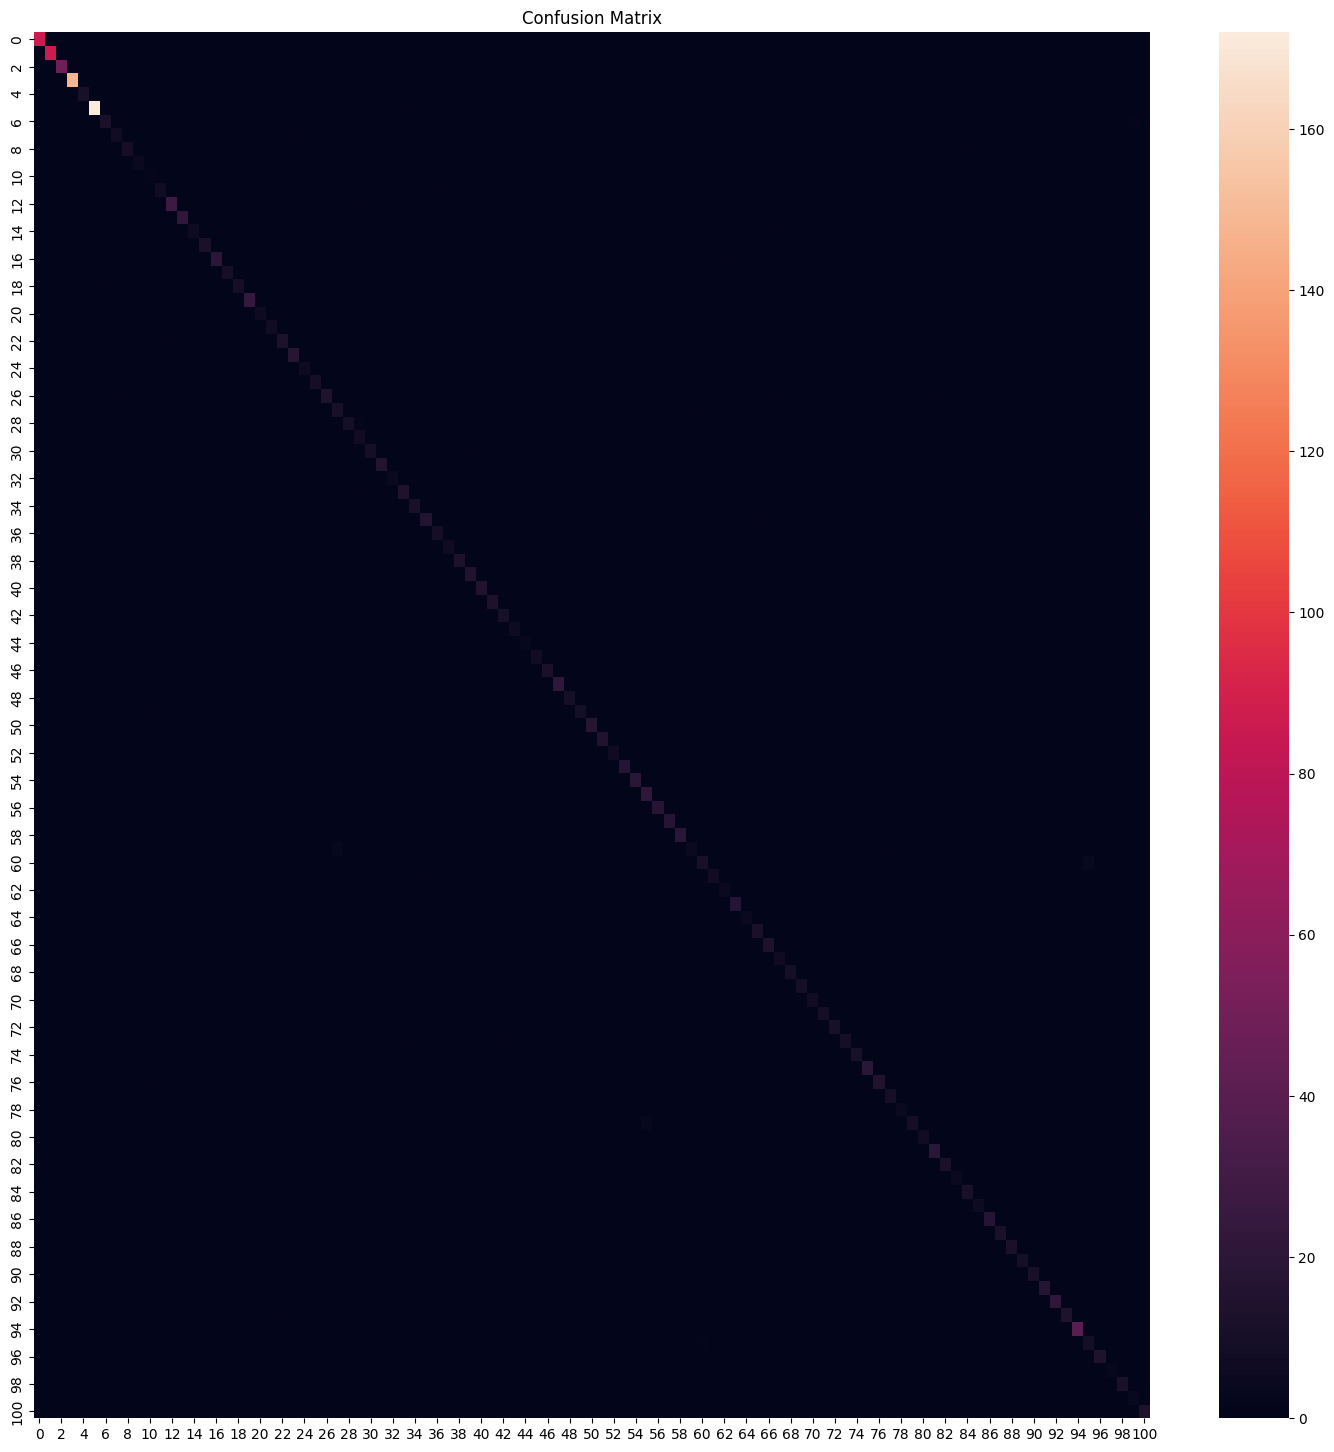

In [ ]:
@torch.no_grad()
def plot_confusion_matrix(model):

    model.eval()

    preds_all = []
    targets_all = []

    for images, targets in val_loader:

        images = images.to(DEVICE)

        outputs = model(images)

        preds = outputs.argmax(dim=1)

        preds_all.extend(
            preds.cpu().numpy()
        )

        targets_all.extend(
            targets.numpy()
        )

    cm = confusion_matrix(
        targets_all,
        preds_all
    )

    plt.figure(figsize=(18, 18))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title('Confusion Matrix')

    plt.show()

    return cm
  cm = plot_confusion_matrix(model)

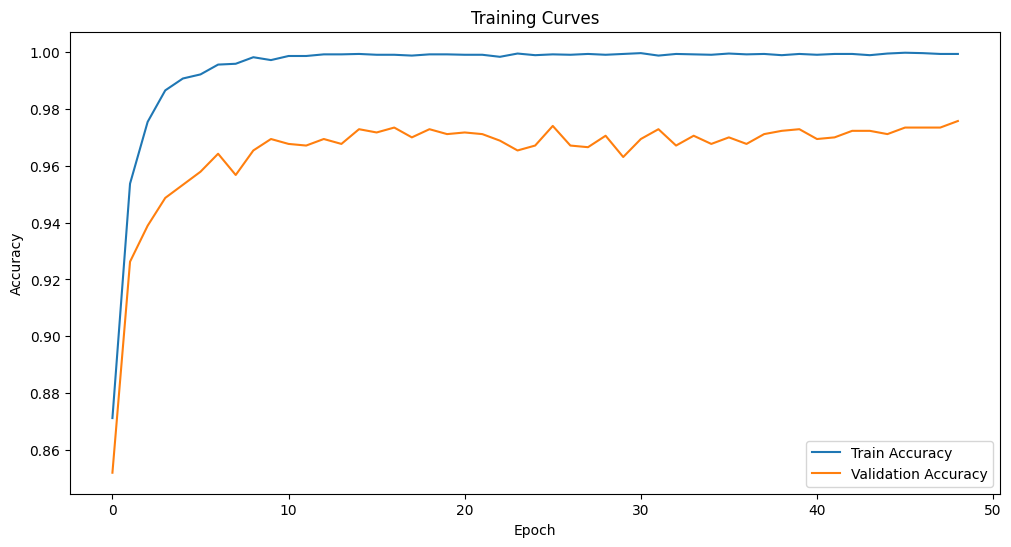

In [ ]:
# ============================================================
# TRAINING CURVES
# ============================================================

history_df = pd.DataFrame(history)

plt.figure(figsize=(12, 6))

plt.plot(
    history_df['train_acc'],
    label='Train Accuracy'
)

plt.plot(
    history_df['val_acc'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.title('Training Curves')

plt.legend()

plt.show()

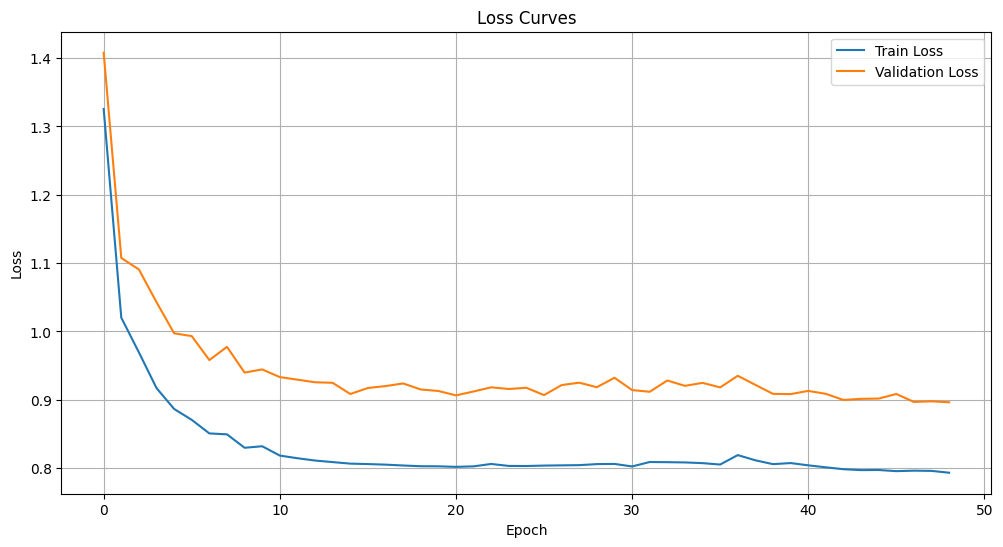

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    history_df['train_loss'],
    label='Train Loss'
)

plt.plot(
    history_df['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title('Loss Curves')

plt.legend()

plt.grid(True)

plt.show()

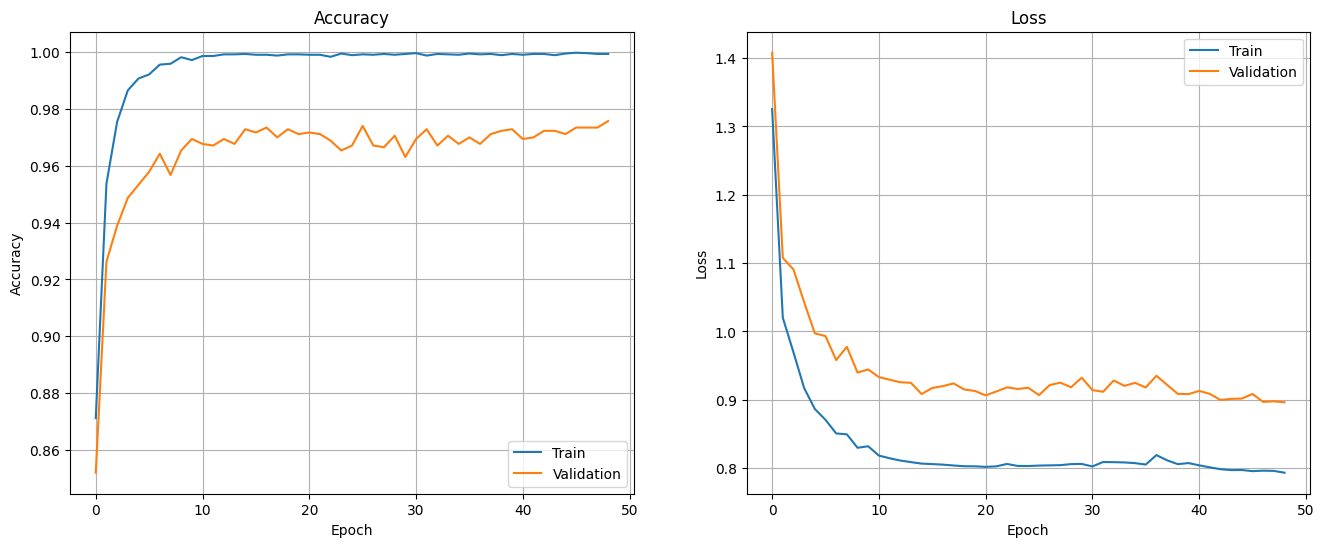

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy
axes[0].plot(history_df['train_acc'], label='Train')
axes[0].plot(history_df['val_acc'], label='Validation')

axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')

axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history_df['train_loss'], label='Train')
axes[1].plot(history_df['val_loss'], label='Validation')

axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')

axes[1].legend()
axes[1].grid(True)

plt.show()

Фурье KAN

In [ ]:
# ============================================================
# IMPORTS
# ============================================================

import os
import json
import random
import numpy as np
import pandas as pd

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

from torchvision import transforms
from torchvision import datasets

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import timm

In [ ]:
# ============================================================
# CONFIG
# ============================================================

DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

BATCH_SIZE = 32

IMAGE_SIZE = 224

NUM_EPOCHS = 1000

LEARNING_RATE = 1e-4

SEED = 42


SAVE_DIR = "/content/drive/MyDrive/VKR additional experiments"

os.makedirs(SAVE_DIR, exist_ok=True)

print("SAVE DIR:", SAVE_DIR)

model_name = 'ResNet50_FourierKAN'

checkpoint_path = os.path.join(
    SAVE_DIR,
    f'{model_name}_best.pth'
)


SAVE DIR: /content/drive/MyDrive/VKR additional experiments


In [ ]:
# ============================================================
# SEED
# ============================================================

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

torch.cuda.manual_seed_all(SEED)

# ============================================================
# TRANSFORMS
# ============================================================

train_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ============================================================
# DATASET
# ============================================================

DATASET_PATH = (
    '/content/drive/MyDrive/caltech101/caltech101/101_ObjectCategories'
)

full_dataset = datasets.ImageFolder(

    root=DATASET_PATH,

    transform=train_transform
)

print('CLASSES:', len(full_dataset.classes))
print('IMAGES:', len(full_dataset))

# ============================================================
# SPLIT
# ============================================================

train_size = int(0.8 * len(full_dataset))

val_size = len(full_dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(

    full_dataset,

    [train_size, val_size]
)

val_dataset.dataset.transform = val_transform

# ============================================================
# DATALOADERS
# ============================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=2,

    pin_memory=True
)

val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=True
)

CLASSES: 101
IMAGES: 8677


In [ ]:
# ============================================================
# FOURIER KAN
# ============================================================

class FourierKANLayer(nn.Module):

    def __init__(self, input_dim, output_dim, n_freq=8):

        super().__init__()

        self.n_freq = n_freq

        self.a = nn.Parameter(
            torch.randn(
                input_dim,
                output_dim,
                n_freq
            ) * 0.01
        )

        self.b = nn.Parameter(
            torch.randn(
                input_dim,
                output_dim,
                n_freq
            ) * 0.01
        )

        self.bias = nn.Parameter(
            torch.zeros(output_dim)
        )

    def forward(self, x):

        x = torch.tanh(x)

        out = 0

        for k in range(self.n_freq):

            out += torch.einsum(
                'bi,io->bo',
                torch.cos((k + 1) * x),
                self.a[:, :, k]
            )

            out += torch.einsum(
                'bi,io->bo',
                torch.sin((k + 1) * x),
                self.b[:, :, k]
            )

        out += self.bias

        return out

# ============================================================
# FULL MODEL
# ============================================================

class ResNetFourierKAN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.backbone = timm.create_model(

            'resnet50',

            pretrained=True,

            num_classes=0,

            global_pool='avg'
        )

        in_features = self.backbone.num_features

        self.classifier = FourierKANLayer(

            input_dim=in_features,

            output_dim=num_classes,

            n_freq=8
        )

    def forward(self, x):

        x = self.backbone(x)

        x = self.classifier(x)

        return x

In [ ]:
# ============================================================
# MODEL
# ============================================================

model = ResNetFourierKAN(

    num_classes=len(full_dataset.classes)

).to(DEVICE)

# ============================================================
# LOSS / OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(

    model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20
)

# ============================================================
# EARLY STOPPING
# ============================================================

class EarlyStopping:

    def __init__(

        self,

        patience=10,

        min_delta=0.0
    ):

        self.patience = patience

        self.min_delta = min_delta

        self.best_loss = np.inf

        self.counter = 0

        self.stop = False

    def __call__(self, val_loss):

        if val_loss < self.best_loss - self.min_delta:

            self.best_loss = val_loss

            self.counter = 0

        else:

            self.counter += 1

            print(
                f'EarlyStopping: {self.counter}/{self.patience}'
            )

            if self.counter >= self.patience:

                self.stop = True

early_stopping = EarlyStopping(

    patience=10,

    min_delta=1e-4
)

# ============================================================
# EVALUATION
# ============================================================

@torch.no_grad()
def evaluate(model, loader, criterion):

    model.eval()

    losses = []

    preds_all = []

    targets_all = []

    for images, targets in loader:

        images = images.to(DEVICE)
        targets = targets.to(DEVICE)

        with torch.amp.autocast(
            device_type='cuda',
            enabled=torch.cuda.is_available()
        ):

            outputs = model(images)

            loss = criterion(outputs, targets)

        losses.append(loss.item())

        preds = outputs.argmax(dim=1)

        preds_all.extend(
            preds.cpu().numpy()
        )

        targets_all.extend(
            targets.cpu().numpy()
        )

    metrics = {

        'loss': np.mean(losses),

        'accuracy': accuracy_score(
            targets_all,
            preds_all
        ),

        'precision': precision_score(
            targets_all,
            preds_all,
            average='macro',
            zero_division=0
        ),

        'recall': recall_score(
            targets_all,
            preds_all,
            average='macro',
            zero_division=0
        ),

        'f1': f1_score(
            targets_all,
            preds_all,
            average='macro',
            zero_division=0
        )
    }

    return metrics

# ============================================================
# AMP
# ============================================================

scaler = torch.amp.GradScaler(

    'cuda',

    enabled=torch.cuda.is_available()
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

In [ ]:
# ============================================================
# TRAINING
# ============================================================

history = []

best_acc = 0

start_epoch = 0

# ============================================================
# EARLY STOPPING
# ============================================================

class EarlyStopping:

    def __init__(

        self,

        patience=8,

        min_delta=1e-4
    ):

        self.patience = patience

        self.min_delta = min_delta

        self.best_loss = np.inf

        self.counter = 0

        self.stop = False

    def __call__(self, val_loss):

        if val_loss < self.best_loss - self.min_delta:

            self.best_loss = val_loss

            self.counter = 0

        else:

            self.counter += 1

            print(
                f'EarlyStopping: '
                f'{self.counter}/{self.patience}'
            )

            if self.counter >= self.patience:

                self.stop = True

early_stopping = EarlyStopping()

# ============================================================
# RESUME CHECKPOINT
# ============================================================

if os.path.exists(checkpoint_path):

    checkpoint = torch.load(

        checkpoint_path,

        map_location=DEVICE
    )

    model.load_state_dict(
        checkpoint['model_state_dict']
    )

    optimizer.load_state_dict(
        checkpoint['optimizer_state_dict']
    )

    scheduler.load_state_dict(
        checkpoint['scheduler_state_dict']
    )

    best_acc = checkpoint['best_acc']

    history = checkpoint['history']

    start_epoch = checkpoint['epoch'] + 1

    # ========================================================
    # RESTORE EARLY STOPPING
    # ========================================================

    early_stopping.counter = checkpoint.get(
        'early_stopping_counter',
        0
    )

    early_stopping.best_loss = checkpoint.get(
        'early_stopping_best_loss',
        np.inf
    )

    print('CHECKPOINT LOADED')

    print(f'START EPOCH: {start_epoch}')

    print(f'BEST ACC: {best_acc:.4f}')

# ============================================================
# AMP
# ============================================================

scaler = torch.amp.GradScaler(

    'cuda',

    enabled=torch.cuda.is_available()
)

# ============================================================
# TRAIN LOOP
# ============================================================

for epoch in range(start_epoch, NUM_EPOCHS):

    model.train()

    train_losses = []

    train_preds = []

    train_targets = []

    loop = tqdm(train_loader)

    for images, targets in loop:

        images = images.to(DEVICE)

        targets = targets.to(DEVICE)

        optimizer.zero_grad()

        # ====================================================
        # MIXED PRECISION
        # ====================================================

        with torch.amp.autocast(

            device_type='cuda',

            enabled=torch.cuda.is_available()
        ):

            outputs = model(images)

            loss = criterion(outputs, targets)

        # ====================================================
        # BACKPROP
        # ====================================================

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            1.0
        )

        scaler.step(optimizer)

        scaler.update()

        # ====================================================
        # TRAIN METRICS
        # ====================================================

        train_losses.append(loss.item())

        preds = outputs.argmax(dim=1)

        train_preds.extend(
            preds.detach().cpu().numpy()
        )

        train_targets.extend(
            targets.detach().cpu().numpy()
        )

        loop.set_description(
            f'Epoch {epoch+1}'
        )

        loop.set_postfix(
            loss=loss.item()
        )

    # ========================================================
    # SCHEDULER
    # ========================================================

    scheduler.step()

    # ========================================================
    # TRAIN METRICS
    # ========================================================

    train_loss = np.mean(train_losses)

    train_acc = accuracy_score(

        train_targets,

        train_preds
    )

    # ========================================================
    # VALIDATION
    # ========================================================

    val_metrics = evaluate(

        model,

        val_loader,

        criterion
    )

    # ========================================================
    # RESULTS
    # ========================================================

    result = {

        'epoch': epoch + 1,

        'train_loss': float(train_loss),

        'val_loss': float(
            val_metrics['loss']
        ),

        'train_acc': float(train_acc),

        'val_acc': float(
            val_metrics['accuracy']
        ),

        'precision': float(
            val_metrics['precision']
        ),

        'recall': float(
            val_metrics['recall']
        ),

        'f1': float(
            val_metrics['f1']
        )
    }

    history.append(result)

    print(result)

    # ========================================================
    # SAVE LAST CHECKPOINT
    # ========================================================

    torch.save({

        'epoch': epoch,

        'model_state_dict': model.state_dict(),

        'optimizer_state_dict': optimizer.state_dict(),

        'scheduler_state_dict': scheduler.state_dict(),

        'best_acc': best_acc,

        'history': history,

        'early_stopping_counter':
            early_stopping.counter,

        'early_stopping_best_loss':
            early_stopping.best_loss

    },

    os.path.join(

        SAVE_DIR,

        f'{model_name}_last.pth'
    ))

    # ========================================================
    # SAVE BEST CHECKPOINT
    # ========================================================

    if val_metrics['accuracy'] > best_acc:

        best_acc = val_metrics['accuracy']

        torch.save({

            'epoch': epoch,

            'model_state_dict': model.state_dict(),

            'optimizer_state_dict': optimizer.state_dict(),

            'scheduler_state_dict': scheduler.state_dict(),

            'best_acc': best_acc,

            'history': history,

            'early_stopping_counter':
                early_stopping.counter,

            'early_stopping_best_loss':
                early_stopping.best_loss

        }, checkpoint_path)

        print(
            f'BEST CHECKPOINT SAVED: '
            f'{best_acc:.4f}'
        )

    # ========================================================
    # EARLY STOPPING
    # ========================================================

    early_stopping(
        val_metrics['loss']
    )

    if early_stopping.stop:

        print('EARLY STOPPING')

        break

# ============================================================
# SAVE HISTORY CSV
# ============================================================

history_df = pd.DataFrame(history)

history_df.to_csv(

    os.path.join(

        SAVE_DIR,

        f'{model_name}_history.csv'
    ),

    index=False
)

print('TRAINING FINISHED')



Epoch 1: 100%|██████████| 217/217 [1:17:28<00:00, 21.42s/it, loss=0.873]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'epoch': 1, 'train_loss': 1.8637660738372583, 'val_loss': 0.43728441474112595, 'train_acc': 0.6258464198242328, 'val_acc': 0.8922811059907834, 'precision': 0.8434505132300238, 'recall': 0.8192283109070428, 'f1': 0.806998656278169}
BEST CHECKPOINT SAVED: 0.8923


  0%|          | 0/217 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch 2:  99%|█████████▉| 215/217 [1:20:25<00:44, 22.32s/it, loss=0.286]

In [ ]:
# ============================================================
# CONTINUE TRAINING FROM CHECKPOINT
# ============================================================

import os
import json
import numpy as np
import pandas as pd

from tqdm import tqdm

import torch
from sklearn.metrics import accuracy_score

# ============================================================
# PATHS
# ============================================================

best_checkpoint_path = os.path.join(
    SAVE_DIR,
    f'{model_name}_best.pth'
)

last_checkpoint_path = os.path.join(
    SAVE_DIR,
    f'{model_name}_last.pth'
)

# ============================================================
# EARLY STOPPING
# ============================================================

class EarlyStopping:

    def __init__(

        self,

        patience=8,

        min_delta=1e-4
    ):

        self.patience = patience

        self.min_delta = min_delta

        self.best_loss = np.inf

        self.counter = 0

        self.stop = False

    def __call__(self, val_loss):

        if val_loss < self.best_loss - self.min_delta:

            self.best_loss = val_loss

            self.counter = 0

        else:

            self.counter += 1

            print(
                f'EarlyStopping: '
                f'{self.counter}/{self.patience}'
            )

            if self.counter >= self.patience:

                self.stop = True

# ============================================================
# INIT
# ============================================================

history = []

best_acc = 0

start_epoch = 0

early_stopping = EarlyStopping()

# ============================================================
# LOAD CHECKPOINT
# ============================================================

if os.path.exists(last_checkpoint_path):

    checkpoint = torch.load(

    last_checkpoint_path,

    map_location=DEVICE,

    weights_only=False
)

    model.load_state_dict(
        checkpoint['model_state_dict']
    )

    optimizer.load_state_dict(
        checkpoint['optimizer_state_dict']
    )

    scheduler.load_state_dict(
        checkpoint['scheduler_state_dict']
    )

    best_acc = checkpoint['best_acc']

    history = checkpoint['history']

    start_epoch = checkpoint['epoch'] + 1

    # ========================================================
    # RESTORE EARLY STOPPING
    # ========================================================

    early_stopping.counter = checkpoint.get(
        'early_stopping_counter',
        0
    )

    early_stopping.best_loss = checkpoint.get(
        'early_stopping_best_loss',
        np.inf
    )

    print('=' * 50)

    print('CHECKPOINT LOADED')

    print(f'START EPOCH: {start_epoch}')

    print(f'BEST ACC: {best_acc:.4f}')

    print('=' * 50)

else:

    print('NO CHECKPOINT FOUND')

# ============================================================
# AMP
# ============================================================

scaler = torch.amp.GradScaler(

    'cuda',

    enabled=torch.cuda.is_available()
)

# ============================================================
# TRAIN LOOP
# ============================================================

for epoch in range(start_epoch, NUM_EPOCHS):

    model.train()

    train_losses = []

    train_preds = []

    train_targets = []

    loop = tqdm(train_loader)

    for images, targets in loop:

        images = images.to(DEVICE)

        targets = targets.to(DEVICE)

        optimizer.zero_grad()

        # ====================================================
        # MIXED PRECISION
        # ====================================================

        with torch.amp.autocast(

            device_type='cuda',

            enabled=torch.cuda.is_available()
        ):

            outputs = model(images)

            loss = criterion(outputs, targets)

        # ====================================================
        # BACKPROP
        # ====================================================

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            1.0
        )

        scaler.step(optimizer)

        scaler.update()

        # ====================================================
        # TRAIN METRICS
        # ====================================================

        train_losses.append(loss.item())

        preds = outputs.argmax(dim=1)

        train_preds.extend(
            preds.detach().cpu().numpy()
        )

        train_targets.extend(
            targets.detach().cpu().numpy()
        )

        loop.set_description(
            f'Epoch {epoch+1}'
        )

        loop.set_postfix(
            loss=loss.item()
        )

    # ========================================================
    # SCHEDULER
    # ========================================================

    scheduler.step()

    # ========================================================
    # TRAIN METRICS
    # ========================================================

    train_loss = np.mean(train_losses)

    train_acc = accuracy_score(

        train_targets,

        train_preds
    )

    # ========================================================
    # VALIDATION
    # ========================================================

    val_metrics = evaluate(

        model,

        val_loader,

        criterion
    )

    # ========================================================
    # RESULTS
    # ========================================================

    result = {

        'epoch': epoch + 1,

        'train_loss': float(train_loss),

        'val_loss': float(
            val_metrics['loss']
        ),

        'train_acc': float(train_acc),

        'val_acc': float(
            val_metrics['accuracy']
        ),

        'precision': float(
            val_metrics['precision']
        ),

        'recall': float(
            val_metrics['recall']
        ),

        'f1': float(
            val_metrics['f1']
        )
    }

    history.append(result)

    print('\n')

    print(result)

    # ========================================================
    # SAVE LAST CHECKPOINT
    # ========================================================

    torch.save({

        'epoch': epoch,

        'model_state_dict': model.state_dict(),

        'optimizer_state_dict': optimizer.state_dict(),

        'scheduler_state_dict': scheduler.state_dict(),

        'best_acc': best_acc,

        'history': history,

        'early_stopping_counter':
            early_stopping.counter,

        'early_stopping_best_loss':
            early_stopping.best_loss

    },

    last_checkpoint_path)

    print('LAST CHECKPOINT SAVED')

    # ========================================================
    # SAVE BEST CHECKPOINT
    # ========================================================

    if val_metrics['accuracy'] > best_acc:

        best_acc = val_metrics['accuracy']

        torch.save({

            'epoch': epoch,

            'model_state_dict': model.state_dict(),

            'optimizer_state_dict': optimizer.state_dict(),

            'scheduler_state_dict': scheduler.state_dict(),

            'best_acc': best_acc,

            'history': history,

            'early_stopping_counter':
                early_stopping.counter,

            'early_stopping_best_loss':
                early_stopping.best_loss

        },

        best_checkpoint_path)

        print(
            f'BEST CHECKPOINT SAVED: '
            f'{best_acc:.4f}'
        )

    # ========================================================
    # EARLY STOPPING
    # ========================================================

    early_stopping(
        val_metrics['loss']
    )

    if early_stopping.stop:

        print('\nEARLY STOPPING')

        break

# ============================================================
# SAVE HISTORY CSV
# ============================================================

history_df = pd.DataFrame(history)

history_df.to_csv(

    os.path.join(

        SAVE_DIR,

        f'{model_name}_history.csv'
    ),

    index=False
)

print('\nTRAINING FINISHED')

CHECKPOINT LOADED
START EPOCH: 2
BEST ACC: 0.8923


  0%|          | 0/217 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch 3: 100%|██████████| 217/217 [1:20:39<00:00, 22.30s/it, loss=0.0899]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)




{'epoch': 3, 'train_loss': 0.14727863624760631, 'val_loss': 0.21630785122767768, 'train_acc': 0.9579311338423858, 'val_acc': 0.9412442396313364, 'precision': 0.9114108089865224, 'recall': 0.9088149434886746, 'f1': 0.8989863165829258}
LAST CHECKPOINT SAVED
BEST CHECKPOINT SAVED: 0.9412


  0%|          | 0/217 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch 4: 100%|██████████| 217/217 [1:25:13<00:00, 23.57s/it, loss=0.117]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)




{'epoch': 4, 'train_loss': 0.08948954594069941, 'val_loss': 0.22028318830363622, 'train_acc': 0.9750756375162081, 'val_acc': 0.9516129032258065, 'precision': 0.9333617790311568, 'recall': 0.9305124104985641, 'f1': 0.9229424885213323}
LAST CHECKPOINT SAVED
BEST CHECKPOINT SAVED: 0.9516
EarlyStopping: 1/8


  0%|          | 0/217 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch 5:  97%|█████████▋| 211/217 [1:22:11<02:20, 23.40s/it, loss=0.000718]

In [ ]:
# ============================================================
# CONTINUE TRAINING FROM CHECKPOINT
# ============================================================

import os
import json
import numpy as np
import pandas as pd

from tqdm import tqdm

import torch
from sklearn.metrics import accuracy_score

# ============================================================
# PATHS
# ============================================================

best_checkpoint_path = os.path.join(
    SAVE_DIR,
    f'{model_name}_best.pth'
)

last_checkpoint_path = os.path.join(
    SAVE_DIR,
    f'{model_name}_last.pth'
)

# ============================================================
# EARLY STOPPING
# ============================================================

class EarlyStopping:

    def __init__(

        self,

        patience=8,

        min_delta=1e-4
    ):

        self.patience = patience

        self.min_delta = min_delta

        self.best_loss = np.inf

        self.counter = 0

        self.stop = False

    def __call__(self, val_loss):

        if val_loss < self.best_loss - self.min_delta:

            self.best_loss = val_loss

            self.counter = 0

        else:

            self.counter += 1

            print(
                f'EarlyStopping: '
                f'{self.counter}/{self.patience}'
            )

            if self.counter >= self.patience:

                self.stop = True

# ============================================================
# INIT
# ============================================================

history = []

best_acc = 0

start_epoch = 0

early_stopping = EarlyStopping()

# ============================================================
# LOAD CHECKPOINT
# ============================================================

if os.path.exists(last_checkpoint_path):

    checkpoint = torch.load(

    last_checkpoint_path,

    map_location=DEVICE,

    weights_only=False
)

    model.load_state_dict(
        checkpoint['model_state_dict']
    )

    optimizer.load_state_dict(
        checkpoint['optimizer_state_dict']
    )

    scheduler.load_state_dict(
        checkpoint['scheduler_state_dict']
    )

    best_acc = checkpoint['best_acc']

    history = checkpoint['history']

    start_epoch = checkpoint['epoch'] + 1

    # ========================================================
    # RESTORE EARLY STOPPING
    # ========================================================

    early_stopping.counter = checkpoint.get(
        'early_stopping_counter',
        0
    )

    early_stopping.best_loss = checkpoint.get(
        'early_stopping_best_loss',
        np.inf
    )

    print('=' * 50)

    print('CHECKPOINT LOADED')

    print(f'START EPOCH: {start_epoch}')

    print(f'BEST ACC: {best_acc:.4f}')

    print('=' * 50)

else:

    print('NO CHECKPOINT FOUND')

# ============================================================
# AMP
# ============================================================

scaler = torch.amp.GradScaler(

    'cuda',

    enabled=torch.cuda.is_available()
)

# ============================================================
# TRAIN LOOP
# ============================================================

for epoch in range(start_epoch, NUM_EPOCHS):

    model.train()

    train_losses = []

    train_preds = []

    train_targets = []

    loop = tqdm(train_loader)

    for images, targets in loop:

        images = images.to(DEVICE)

        targets = targets.to(DEVICE)

        optimizer.zero_grad()

        # ====================================================
        # MIXED PRECISION
        # ====================================================

        with torch.amp.autocast(

            device_type='cuda',

            enabled=torch.cuda.is_available()
        ):

            outputs = model(images)

            loss = criterion(outputs, targets)

        # ====================================================
        # BACKPROP
        # ====================================================

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            1.0
        )

        scaler.step(optimizer)

        scaler.update()

        # ====================================================
        # TRAIN METRICS
        # ====================================================

        train_losses.append(loss.item())

        preds = outputs.argmax(dim=1)

        train_preds.extend(
            preds.detach().cpu().numpy()
        )

        train_targets.extend(
            targets.detach().cpu().numpy()
        )

        loop.set_description(
            f'Epoch {epoch+1}'
        )

        loop.set_postfix(
            loss=loss.item()
        )

    # ========================================================
    # SCHEDULER
    # ========================================================

    scheduler.step()

    # ========================================================
    # TRAIN METRICS
    # ========================================================

    train_loss = np.mean(train_losses)

    train_acc = accuracy_score(

        train_targets,

        train_preds
    )

    # ========================================================
    # VALIDATION
    # ========================================================

    val_metrics = evaluate(

        model,

        val_loader,

        criterion
    )

    # ========================================================
    # RESULTS
    # ========================================================

    result = {

        'epoch': epoch + 1,

        'train_loss': float(train_loss),

        'val_loss': float(
            val_metrics['loss']
        ),

        'train_acc': float(train_acc),

        'val_acc': float(
            val_metrics['accuracy']
        ),

        'precision': float(
            val_metrics['precision']
        ),

        'recall': float(
            val_metrics['recall']
        ),

        'f1': float(
            val_metrics['f1']
        )
    }

    history.append(result)

    print('\n')

    print(result)

    # ========================================================
    # SAVE LAST CHECKPOINT
    # ========================================================

    torch.save({

        'epoch': epoch,

        'model_state_dict': model.state_dict(),

        'optimizer_state_dict': optimizer.state_dict(),

        'scheduler_state_dict': scheduler.state_dict(),

        'best_acc': best_acc,

        'history': history,

        'early_stopping_counter':
            early_stopping.counter,

        'early_stopping_best_loss':
            early_stopping.best_loss

    },

    last_checkpoint_path)

    print('LAST CHECKPOINT SAVED')

    # ========================================================
    # SAVE BEST CHECKPOINT
    # ========================================================

    if val_metrics['accuracy'] > best_acc:

        best_acc = val_metrics['accuracy']

        torch.save({

            'epoch': epoch,

            'model_state_dict': model.state_dict(),

            'optimizer_state_dict': optimizer.state_dict(),

            'scheduler_state_dict': scheduler.state_dict(),

            'best_acc': best_acc,

            'history': history,

            'early_stopping_counter':
                early_stopping.counter,

            'early_stopping_best_loss':
                early_stopping.best_loss

        },

        best_checkpoint_path)

        print(
            f'BEST CHECKPOINT SAVED: '
            f'{best_acc:.4f}'
        )

    # ========================================================
    # EARLY STOPPING
    # ========================================================

    early_stopping(
        val_metrics['loss']
    )

    if early_stopping.stop:

        print('\nEARLY STOPPING')

        break

# ============================================================
# SAVE HISTORY CSV
# ============================================================

history_df = pd.DataFrame(history)

history_df.to_csv(

    os.path.join(

        SAVE_DIR,

        f'{model_name}_history.csv'
    ),

    index=False
)

print('\nTRAINING FINISHED')

CHECKPOINT LOADED
START EPOCH: 5
BEST ACC: 0.9516


Epoch 6: 100%|██████████| 217/217 [23:20<00:00,  6.45s/it, loss=0.00171]




{'epoch': 6, 'train_loss': 0.01866638790740962, 'val_loss': 0.2719358804551038, 'train_acc': 0.9953897132977957, 'val_acc': 0.9447004608294931, 'precision': 0.9312610609153307, 'recall': 0.9143613784760743, 'f1': 0.9105763549048832}
LAST CHECKPOINT SAVED
EarlyStopping: 2/8


Epoch 7: 100%|██████████| 217/217 [00:54<00:00,  3.96it/s, loss=0.000186]




{'epoch': 7, 'train_loss': 0.011681049836054874, 'val_loss': 0.17545459128238938, 'train_acc': 0.9974067137300101, 'val_acc': 0.9654377880184332, 'precision': 0.9503594854015684, 'recall': 0.947750706645714, 'f1': 0.9447183653122856}
LAST CHECKPOINT SAVED
BEST CHECKPOINT SAVED: 0.9654


...



{'epoch': 14, 'train_loss': 0.003761693687861665, 'val_loss': 0.1881211552430283, 'train_acc': 0.9994237141622244, 'val_acc': 0.9654377880184332, 'precision': 0.9496314250989132, 'recall': 0.9478096467672634, 'f1': 0.9441733222592649}
LAST CHECKPOINT SAVED
EarlyStopping: 6/8


Epoch 15: 100%|██████████| 217/217 [00:54<00:00,  3.95it/s, loss=1.69e-5]




{'epoch': 15, 'train_loss': 0.0037473781366177653, 'val_loss': 0.18834228698502886, 'train_acc': 0.9992796427027806, 'val_acc': 0.9642857142857143, 'precision': 0.95085029810896, 'recall': 0.9459718312791859, 'f1': 0.9440050151896778}
LAST CHECKPOINT SAVED
EarlyStopping: 7/8


Epoch 16: 100%|██████████| 217/217 [00:55<00:00,  3.88it/s, loss=0.00094]




{'epoch': 16, 'train_loss': 0.0022895800962095675, 'val_loss': 0.17563125389543446, 'train_acc': 0.9994237141622244, 'val_acc': 0.9671658986175116, 'precision': 0.9530207487052068, 'recall': 0.9516572939754231, 'f1': 0.947852523085928}
LAST CHECKPOINT SAVED
BEST CHECKPOINT SAVED: 0.9672
EarlyStopping: 8/8

EARLY STOPPING

TRAINING FINISHED


   epoch  train_loss  val_loss  train_acc   val_acc  precision    recall  \
0      1    1.863766  0.437284   0.625846  0.892281   0.843451  0.819228   
1      2    0.333430  0.314256   0.914998  0.925691   0.902863  0.878551   
2      3    0.147279  0.216308   0.957931  0.941244   0.911411  0.908815   
3      4    0.089490  0.220283   0.975076  0.951613   0.933362  0.930512   
4      5    0.044103  0.194050   0.988474  0.955645   0.937883  0.920382   

         f1  
0  0.806999  
1  0.873415  
2  0.898986  
3  0.922942  
4  0.922116  


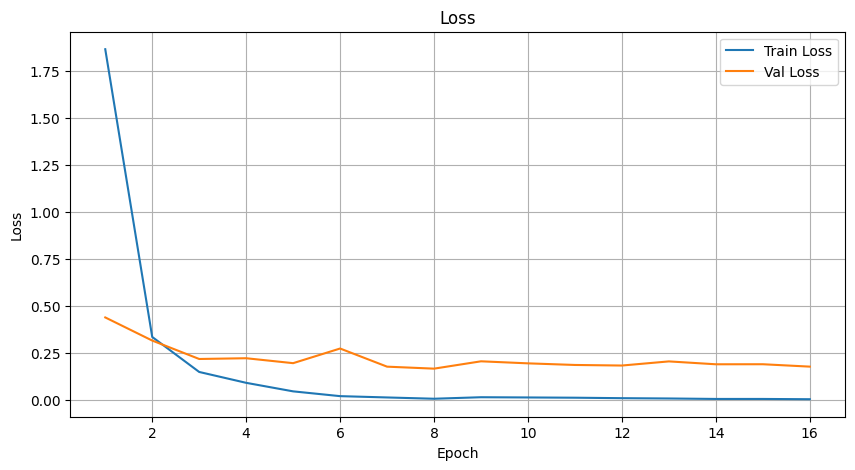

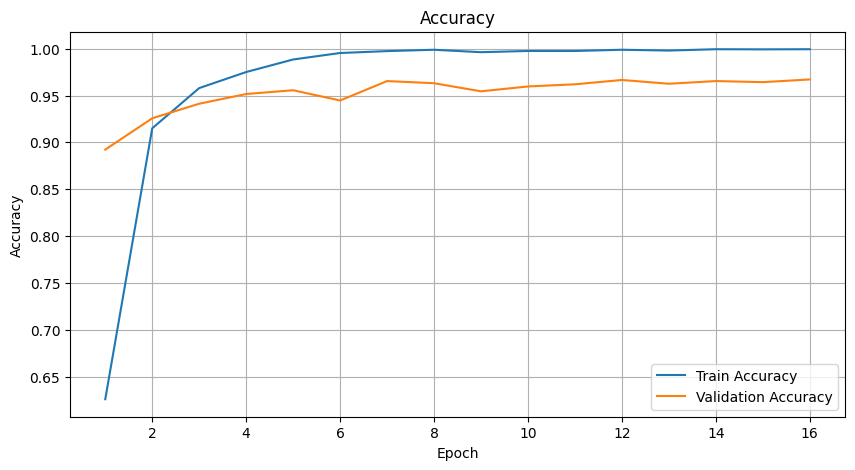

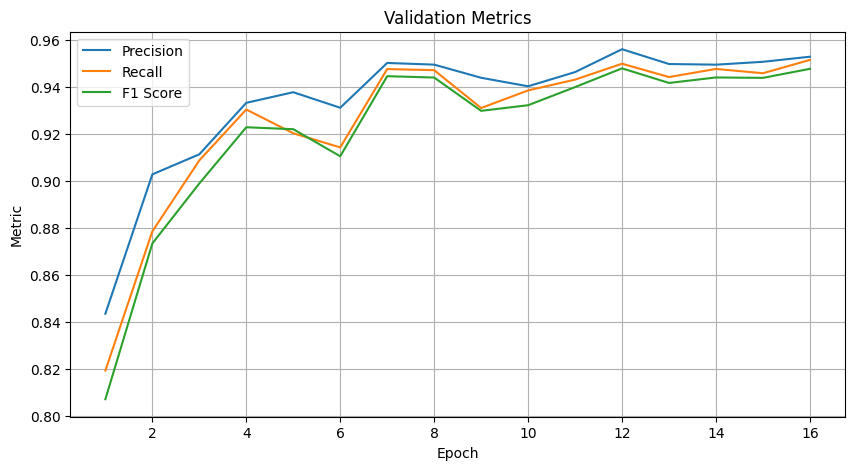

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# HISTORY DATAFRAME
# ============================================================

history_df = pd.DataFrame(history)

print(history_df.head())

# ============================================================
# LOSS
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history_df['epoch'],
    history_df['train_loss'],
    label='Train Loss'
)

plt.plot(
    history_df['epoch'],
    history_df['val_loss'],
    label='Val Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title('Loss')

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# ACCURACY
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history_df['epoch'],
    history_df['train_acc'],
    label='Train Accuracy'
)

plt.plot(
    history_df['epoch'],
    history_df['val_acc'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.title('Accuracy')

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# PRECISION / RECALL / F1
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history_df['epoch'],
    history_df['precision'],
    label='Precision'
)

plt.plot(
    history_df['epoch'],
    history_df['recall'],
    label='Recall'
)

plt.plot(
    history_df['epoch'],
    history_df['f1'],
    label='F1 Score'
)

plt.xlabel('Epoch')
plt.ylabel('Metric')

plt.title('Validation Metrics')

plt.legend()

plt.grid(True)

plt.show()

Лежандр KAN

In [ ]:
# ============================================================
# IMPORTS
# ============================================================

import os
import json
import random
import numpy as np
import pandas as pd

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

from torchvision import transforms
from torchvision import datasets

import timm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


In [ ]:
# ============================================================
# CONFIG
# ============================================================

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

NUM_CLASSES = 102

BATCH_SIZE = 32

NUM_EPOCHS = 100

IMAGE_SIZE = 224

LR = 1e-4

SAVE_DIR = '/content/drive/MyDrive/VKR additional experiments/legendre_kan'

os.makedirs(SAVE_DIR, exist_ok=True)

model_name = 'resnet50_legendre_kan'

best_checkpoint_path = os.path.join(
    SAVE_DIR,
    f'{model_name}_best.pth'
)

last_checkpoint_path = os.path.join(
    SAVE_DIR,
    f'{model_name}_last.pth'
)

# ============================================================
# DATASET
# ============================================================

DATASET_PATH = (
    '/content/drive/MyDrive/caltech101/caltech101/101_ObjectCategories'
)

# ============================================================
# TRANSFORMS
# ============================================================

train_transform = transforms.Compose([

    transforms.Resize((256, 256)),

    transforms.RandomCrop(IMAGE_SIZE),

    transforms.RandomHorizontalFlip(),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485, 0.456, 0.406],

        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485, 0.456, 0.406],

        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
# ============================================================
# DATASET
# ============================================================

full_dataset = datasets.ImageFolder(

    root=DATASET_PATH,

    transform=train_transform
)

train_size = int(0.8 * len(full_dataset))

val_size = len(full_dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(

    full_dataset,

    [train_size, val_size]
)

val_dataset.dataset.transform = val_transform

# ============================================================
# DATALOADERS
# ============================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=2,

    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=torch.cuda.is_available()
)

print('TRAIN:', len(train_dataset))

print('VAL:', len(val_dataset))


TRAIN: 6941
VAL: 1736


In [ ]:
# ============================================================
# LEGENDRE KAN
# ============================================================

class LegendreKANLayer(nn.Module):

    def __init__(

        self,

        input_dim,

        output_dim,

        degree=6
    ):

        super().__init__()

        self.degree = degree

        self.coeffs = nn.Parameter(

            torch.randn(

                input_dim,

                output_dim,

                degree + 1

            ) * 0.01
        )

    def compute_legendre(self, x):

        P = [torch.ones_like(x)]

        if self.degree >= 1:

            P.append(x)

        for n in range(2, self.degree + 1):

            pn = (

                ((2 * n - 1) * x * P[n - 1])

                - ((n - 1) * P[n - 2])

            ) / n

            P.append(pn)

        return torch.stack(P, dim=-1)

    def forward(self, x):

        x = torch.tanh(x)

        polys = self.compute_legendre(x)

        out = torch.einsum(

            'bid,iod->bo',

            polys,

            self.coeffs
        )

        return out

# ============================================================
# CLASSIFIER
# ============================================================

class LegendreKANClassifier(nn.Module):

    def __init__(

        self,

        input_dim,

        num_classes
    ):

        super().__init__()

        self.layer1 = LegendreKANLayer(

            input_dim,

            512,

            degree=6
        )

        self.norm1 = nn.LayerNorm(512)

        self.dropout1 = nn.Dropout(0.3)

        self.layer2 = LegendreKANLayer(

            512,

            num_classes,

            degree=6
        )

    def forward(self, x):

        x = self.layer1(x)

        x = self.norm1(x)

        x = torch.relu(x)

        x = self.dropout1(x)

        x = self.layer2(x)

        return x

# ============================================================
# FULL MODEL
# ============================================================

class ResNetLegendreKAN(nn.Module):

    def __init__(

        self,

        num_classes=102
    ):

        super().__init__()

        self.backbone = timm.create_model(

            'resnet50',

            pretrained=True,

            num_classes=0,

            global_pool='avg'
        )

        in_features = self.backbone.num_features

        self.classifier = LegendreKANClassifier(

            in_features,

            num_classes
        )

    def forward(self, x):

        x = self.backbone(x)

        x = self.classifier(x)

        return x


In [ ]:
# ============================================================
# MODEL
# ============================================================

model = ResNetLegendreKAN(

    num_classes=NUM_CLASSES
).to(DEVICE)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

In [ ]:

# ============================================================
# LOSS / OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(

    model.parameters(),

    lr=LR,

    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=NUM_EPOCHS
)

# ============================================================
# EARLY STOPPING
# ============================================================

class EarlyStopping:

    def __init__(

        self,

        patience=8,

        min_delta=1e-4
    ):

        self.patience = patience

        self.min_delta = min_delta

        self.best_loss = np.inf

        self.counter = 0

        self.stop = False

    def __call__(self, val_loss):

        if val_loss < self.best_loss - self.min_delta:

            self.best_loss = val_loss

            self.counter = 0

        else:

            self.counter += 1

            print(
                f'EarlyStopping: '
                f'{self.counter}/{self.patience}'
            )

            if self.counter >= self.patience:

                self.stop = True

early_stopping = EarlyStopping()

# ============================================================
# EVALUATE
# ============================================================

@torch.no_grad()
def evaluate(model, loader, criterion):

    model.eval()

    losses = []

    preds_all = []

    targets_all = []

    for images, targets in loader:

        images = images.to(DEVICE)

        targets = targets.to(DEVICE)

        outputs = model(images)

        loss = criterion(outputs, targets)

        preds = outputs.argmax(dim=1)

        losses.append(loss.item())

        preds_all.extend(
            preds.cpu().numpy()
        )

        targets_all.extend(
            targets.cpu().numpy()
        )

    return {

        'loss': np.mean(losses),

        'accuracy': accuracy_score(
            targets_all,
            preds_all
        ),

        'precision': precision_score(
            targets_all,
            preds_all,
            average='macro',
            zero_division=0
        ),

        'recall': recall_score(
            targets_all,
            preds_all,
            average='macro',
            zero_division=0
        ),

        'f1': f1_score(
            targets_all,
            preds_all,
            average='macro',
            zero_division=0
        )
    }

# ============================================================
# RESUME
# ============================================================

history = []

best_acc = 0

start_epoch = 0

if os.path.exists(last_checkpoint_path):

    checkpoint = torch.load(

        last_checkpoint_path,

        map_location=DEVICE,

        weights_only=False
    )

    model.load_state_dict(
        checkpoint['model_state_dict']
    )

    optimizer.load_state_dict(
        checkpoint['optimizer_state_dict']
    )

    scheduler.load_state_dict(
        checkpoint['scheduler_state_dict']
    )

    best_acc = checkpoint['best_acc']

    history = checkpoint['history']

    start_epoch = checkpoint['epoch'] + 1

    early_stopping.counter = checkpoint.get(
        'early_stopping_counter',
        0
    )

    early_stopping.best_loss = checkpoint.get(
        'early_stopping_best_loss',
        np.inf
    )

    print('CHECKPOINT LOADED')

    print(f'START EPOCH: {start_epoch}')

    print(f'BEST ACC: {best_acc:.4f}')

# ============================================================
# AMP
# ============================================================

scaler = torch.amp.GradScaler(

    'cuda',

    enabled=torch.cuda.is_available()
)

# ============================================================
# TRAIN LOOP
# ============================================================

for epoch in range(start_epoch, NUM_EPOCHS):

    model.train()

    train_losses = []

    train_preds = []

    train_targets = []

    loop = tqdm(train_loader)

    for images, targets in loop:

        images = images.to(DEVICE)

        targets = targets.to(DEVICE)

        optimizer.zero_grad()

        with torch.amp.autocast(

            device_type='cuda',

            enabled=torch.cuda.is_available()
        ):

            outputs = model(images)

            loss = criterion(outputs, targets)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            1.0
        )

        scaler.step(optimizer)

        scaler.update()

        train_losses.append(loss.item())

        preds = outputs.argmax(dim=1)

        train_preds.extend(
            preds.detach().cpu().numpy()
        )

        train_targets.extend(
            targets.detach().cpu().numpy()
        )

        loop.set_description(
            f'Epoch {epoch+1}'
        )

        loop.set_postfix(
            loss=loss.item()
        )

    scheduler.step()

    train_loss = np.mean(train_losses)

    train_acc = accuracy_score(

        train_targets,

        train_preds
    )

    val_metrics = evaluate(

        model,

        val_loader,

        criterion
    )

    result = {

        'epoch': epoch + 1,

        'train_loss': float(train_loss),

        'val_loss': float(
            val_metrics['loss']
        ),

        'train_acc': float(train_acc),

        'val_acc': float(
            val_metrics['accuracy']
        ),

        'precision': float(
            val_metrics['precision']
        ),

        'recall': float(
            val_metrics['recall']
        ),

        'f1': float(
            val_metrics['f1']
        )
    }

    history.append(result)

    print('\n')

    print(result)

    # ========================================================
    # SAVE LAST
    # ========================================================

    torch.save({

        'epoch': epoch,

        'model_state_dict': model.state_dict(),

        'optimizer_state_dict': optimizer.state_dict(),

        'scheduler_state_dict': scheduler.state_dict(),

        'best_acc': best_acc,

        'history': history,

        'early_stopping_counter':
            early_stopping.counter,

        'early_stopping_best_loss':
            early_stopping.best_loss

    },

    last_checkpoint_path)

    print('LAST CHECKPOINT SAVED')

    # ========================================================
    # SAVE BEST
    # ========================================================

    if val_metrics['accuracy'] > best_acc:

        best_acc = val_metrics['accuracy']

        torch.save({

            'epoch': epoch,

            'model_state_dict': model.state_dict(),

            'optimizer_state_dict': optimizer.state_dict(),

            'scheduler_state_dict': scheduler.state_dict(),

            'best_acc': best_acc,

            'history': history,

            'early_stopping_counter':
                early_stopping.counter,

            'early_stopping_best_loss':
                early_stopping.best_loss

        },

        best_checkpoint_path)

        print(
            f'BEST CHECKPOINT SAVED: '
            f'{best_acc:.4f}'
        )

    # ========================================================
    # EARLY STOPPING
    # ========================================================

    early_stopping(
        val_metrics['loss']
    )

    if early_stopping.stop:

        print('\nEARLY STOPPING')

        break

# ============================================================
# SAVE HISTORY
# ============================================================

history_df = pd.DataFrame(history)

history_df.to_csv(

    os.path.join(

        SAVE_DIR,

        f'{model_name}_history.csv'
    ),

    index=False
)

print('\nTRAINING FINISHED')

Epoch 1: 100%|██████████| 217/217 [00:45<00:00,  4.75it/s, loss=2.63]




{'epoch': 1, 'train_loss': 3.8560399624609176, 'val_loss': 3.241335387663408, 'train_acc': 0.2038611151130961, 'val_acc': 0.29493087557603687, 'precision': 0.06530176085386964, 'recall': 0.05824364203412567, 'f1': 0.03888382457860566}
LAST CHECKPOINT SAVED
BEST CHECKPOINT SAVED: 0.2949


Epoch 2: 100%|██████████| 217/217 [00:50<00:00,  4.32it/s, loss=2.81]




{'epoch': 2, 'train_loss': 2.7633918221645093, 'val_loss': 2.185056291926991, 'train_acc': 0.46549488546318973, 'val_acc': 0.6226958525345622, 'precision': 0.3470744549716871, 'recall': 0.36985290437466556, 'f1': 0.3197221845716656}
LAST CHECKPOINT SAVED
BEST CHECKPOINT SAVED: 0.6227


Epoch 3: 100%|██████████| 217/217 [01:05<00:00,  3.31it/s, loss=1.3]


...



{'epoch': 18, 'train_loss': 0.003975545126979115, 'val_loss': 0.13141400110378693, 'train_acc': 0.9995677856216684, 'val_acc': 0.9683179723502304, 'precision': 0.9534672845323755, 'recall': 0.9556937065685068, 'f1': 0.9503534465653839}
LAST CHECKPOINT SAVED
EarlyStopping: 6/8


Epoch 19: 100%|██████████| 217/217 [00:56<00:00,  3.83it/s, loss=0.0182]




{'epoch': 19, 'train_loss': 0.0046125689976363685, 'val_loss': 0.13759184721645645, 'train_acc': 0.9994237141622244, 'val_acc': 0.9631336405529954, 'precision': 0.9469441308136083, 'recall': 0.9486085471855163, 'f1': 0.9447777747929755}
LAST CHECKPOINT SAVED
EarlyStopping: 7/8


Epoch 20: 100%|██████████| 217/217 [00:55<00:00,  3.92it/s, loss=0.00174]




{'epoch': 20, 'train_loss': 0.00468761656296006, 'val_loss': 0.1298929581371009, 'train_acc': 0.9994237141622244, 'val_acc': 0.9688940092165899, 'precision': 0.9506345590434371, 'recall': 0.9560074563198406, 'f1': 0.9499922270183646}
LAST CHECKPOINT SAVED
EarlyStopping: 8/8

EARLY STOPPING

TRAINING FINISHED


In [ ]:
history_df = pd.read_csv(
    os.path.join(
        SAVE_DIR,
        f'{model_name}_history.csv'
    )
)

print(history_df.tail())

    epoch  train_loss  val_loss  train_acc   val_acc  precision    recall  \
15     16    0.006649  0.123060   0.999424  0.970622   0.957269  0.957754   
16     17    0.005378  0.121967   0.999424  0.967742   0.951152  0.955420   
17     18    0.003976  0.131414   0.999568  0.968318   0.953467  0.955694   
18     19    0.004613  0.137592   0.999424  0.963134   0.946944  0.948609   
19     20    0.004688  0.129893   0.999424  0.968894   0.950635  0.956007   

          f1  
15  0.953943  
16  0.949535  
17  0.950353  
18  0.944778  
19  0.949992  


   epoch  train_loss  val_loss  train_acc   val_acc  precision    recall  \
0      1    3.856040  3.241335   0.203861  0.294931   0.065302  0.058244   
1      2    2.763392  2.185056   0.465495  0.622696   0.347074  0.369853   
2      3    1.774920  1.233452   0.719925  0.829493   0.675967  0.676127   
3      4    0.964449  0.626408   0.875378  0.883065   0.784043  0.782967   
4      5    0.484253  0.343328   0.939346  0.936060   0.876507  0.893194   

         f1  
0  0.038884  
1  0.319722  
2  0.637241  
3  0.751427  
4  0.872283  


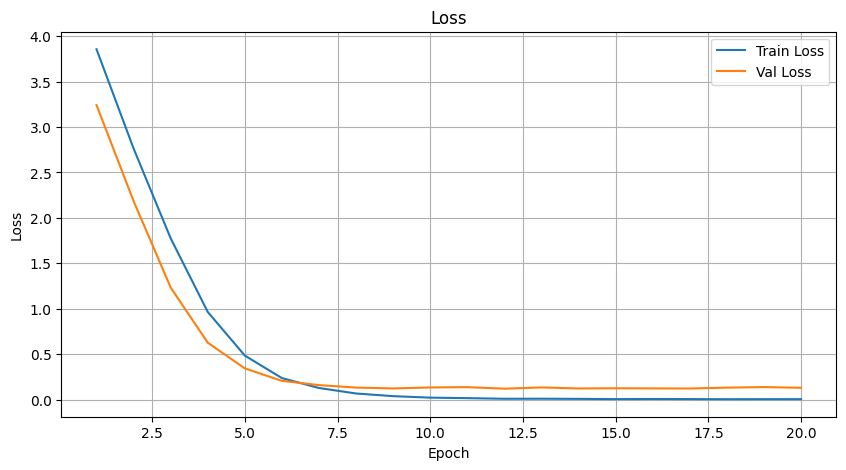

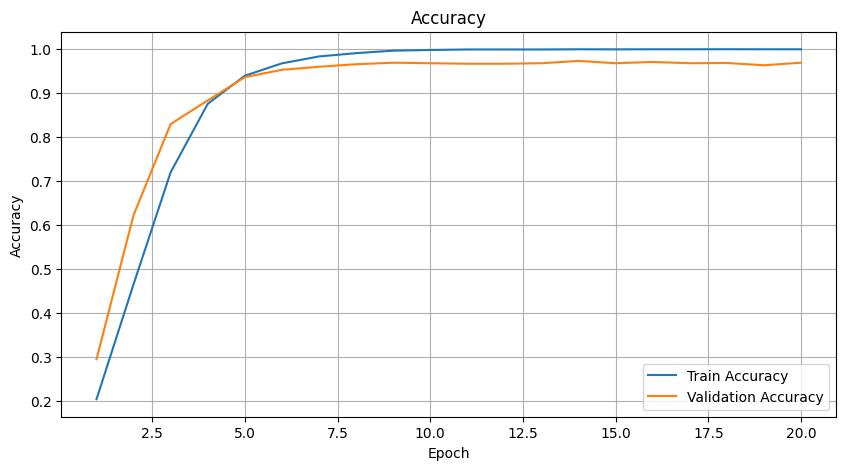

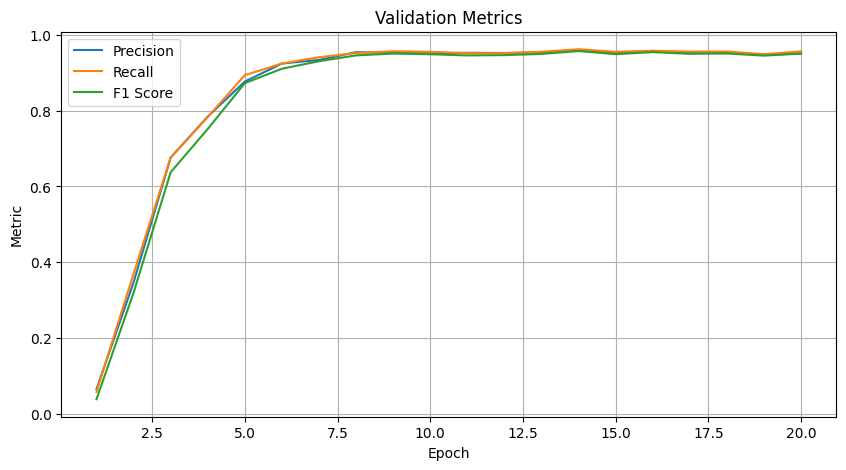

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# HISTORY DATAFRAME
# ============================================================

# history_df = pd.DataFrame(history)

print(history_df.head())

# ============================================================
# LOSS
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history_df['epoch'],
    history_df['train_loss'],
    label='Train Loss'
)

plt.plot(
    history_df['epoch'],
    history_df['val_loss'],
    label='Val Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title('Loss')

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# ACCURACY
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history_df['epoch'],
    history_df['train_acc'],
    label='Train Accuracy'
)

plt.plot(
    history_df['epoch'],
    history_df['val_acc'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.title('Accuracy')

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# PRECISION / RECALL / F1
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history_df['epoch'],
    history_df['precision'],
    label='Precision'
)

plt.plot(
    history_df['epoch'],
    history_df['recall'],
    label='Recall'
)

plt.plot(
    history_df['epoch'],
    history_df['f1'],
    label='F1 Score'
)

plt.xlabel('Epoch')
plt.ylabel('Metric')

plt.title('Validation Metrics')

plt.legend()

plt.grid(True)

plt.show()

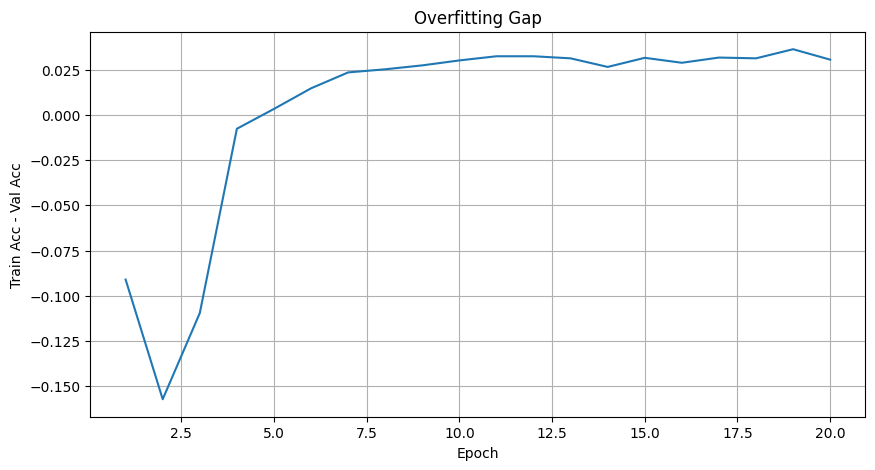

In [ ]:
plt.figure(figsize=(10,5))

gap = (
    history_df['train_acc']
    - history_df['val_acc']
)

plt.plot(
    history_df['epoch'],
    gap
)

plt.xlabel('Epoch')
plt.ylabel('Train Acc - Val Acc')
plt.title('Overfitting Gap')
plt.grid(True)

plt.show()

ЧЕбышев KAN

In [ ]:
# ============================================================
# IMPORTS
# ============================================================

import os
import random
import numpy as np
import pandas as pd

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

from torchvision import transforms
from torchvision import datasets

import timm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# CONFIG
# ============================================================

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

NUM_CLASSES = 102

BATCH_SIZE = 32

NUM_EPOCHS = 100

IMAGE_SIZE = 224

LR = 1e-4

SAVE_DIR = '/content/drive/MyDrive/VKR additional experiments/chebyshev_kan'

os.makedirs(SAVE_DIR, exist_ok=True)

model_name = 'resnet50_chebyshev_kan'

best_checkpoint_path = os.path.join(
    SAVE_DIR,
    f'{model_name}_best.pth'
)

last_checkpoint_path = os.path.join(
    SAVE_DIR,
    f'{model_name}_last.pth'
)

In [ ]:
# ============================================================
# DATASET
# ============================================================

DATASET_PATH = (
    '/content/drive/MyDrive/caltech101/caltech101/101_ObjectCategories'
)

# ============================================================
# TRANSFORMS
# ============================================================

train_transform = transforms.Compose([

    transforms.Resize((256, 256)),

    transforms.RandomCrop(IMAGE_SIZE),

    transforms.RandomHorizontalFlip(),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485, 0.456, 0.406],

        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485, 0.456, 0.406],

        std=[0.229, 0.224, 0.225]
    )
])

# ============================================================
# DATASET
# ============================================================

full_dataset = datasets.ImageFolder(

    root=DATASET_PATH,

    transform=train_transform
)

train_size = int(0.8 * len(full_dataset))

val_size = len(full_dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(

    full_dataset,

    [train_size, val_size]
)

val_dataset.dataset.transform = val_transform

# ============================================================
# DATALOADERS
# ============================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=2,

    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=torch.cuda.is_available()
)

print('TRAIN:', len(train_dataset))

print('VAL:', len(val_dataset))

TRAIN: 6941
VAL: 1736


In [ ]:
# ============================================================
# CHEBYSHEV KAN
# ============================================================

class ChebyshevKANLayer(nn.Module):

    def __init__(

        self,

        input_dim,

        output_dim,

        degree=8
    ):

        super().__init__()

        self.degree = degree

        self.coeffs = nn.Parameter(

            torch.randn(

                input_dim,

                output_dim,

                degree + 1

            ) * 0.01
        )

    def compute_chebyshev(self, x):

        T = [

            torch.ones_like(x),

            x
        ]

        for n in range(2, self.degree + 1):

            tn = (
                2 * x * T[n - 1]
            ) - T[n - 2]

            T.append(tn)

        return torch.stack(T, dim=-1)

    def forward(self, x):

        x = torch.tanh(x)

        polys = self.compute_chebyshev(x)

        out = torch.einsum(

            'bid,iod->bo',

            polys,

            self.coeffs
        )

        return out

# ============================================================
# CLASSIFIER
# ============================================================

class ChebyshevKANClassifier(nn.Module):

    def __init__(

        self,

        input_dim,

        num_classes
    ):

        super().__init__()

        self.layer1 = ChebyshevKANLayer(

            input_dim,

            512,

            degree=8
        )

        self.norm1 = nn.LayerNorm(512)

        self.dropout1 = nn.Dropout(0.3)

        self.layer2 = ChebyshevKANLayer(

            512,

            num_classes,

            degree=8
        )

    def forward(self, x):

        x = self.layer1(x)

        x = self.norm1(x)

        x = torch.relu(x)

        x = self.dropout1(x)

        x = self.layer2(x)

        return x

# ============================================================
# FULL MODEL
# ============================================================

class ResNetChebyshevKAN(nn.Module):

    def __init__(

        self,

        num_classes=102
    ):

        super().__init__()

        self.backbone = timm.create_model(

            'resnet50',

            pretrained=True,

            num_classes=0,

            global_pool='avg'
        )

        in_features = self.backbone.num_features

        self.classifier = ChebyshevKANClassifier(

            in_features,

            num_classes
        )

    def forward(self, x):

        x = self.backbone(x)

        x = self.classifier(x)

        return x


In [ ]:

# ============================================================
# MODEL
# ============================================================

model = ResNetChebyshevKAN(

    num_classes=NUM_CLASSES
).to(DEVICE)

# ============================================================
# LOSS / OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(

    model.parameters(),

    lr=LR,

    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=NUM_EPOCHS
)

# ============================================================
# EARLY STOPPING
# ============================================================

class EarlyStopping:

    def __init__(

        self,

        patience=8,

        min_delta=1e-4
    ):

        self.patience = patience

        self.min_delta = min_delta

        self.best_loss = np.inf

        self.counter = 0

        self.stop = False

    def __call__(self, val_loss):

        if val_loss < self.best_loss - self.min_delta:

            self.best_loss = val_loss

            self.counter = 0

        else:

            self.counter += 1

            print(
                f'EarlyStopping: '
                f'{self.counter}/{self.patience}'
            )

            if self.counter >= self.patience:

                self.stop = True

early_stopping = EarlyStopping()

# ============================================================
# EVALUATE
# ============================================================

@torch.no_grad()
def evaluate(model, loader, criterion):

    model.eval()

    losses = []

    preds_all = []

    targets_all = []

    for images, targets in loader:

        images = images.to(DEVICE)

        targets = targets.to(DEVICE)

        outputs = model(images)

        loss = criterion(outputs, targets)

        preds = outputs.argmax(dim=1)

        losses.append(loss.item())

        preds_all.extend(
            preds.cpu().numpy()
        )

        targets_all.extend(
            targets.cpu().numpy()
        )

    return {

        'loss': np.mean(losses),

        'accuracy': accuracy_score(
            targets_all,
            preds_all
        ),

        'precision': precision_score(
            targets_all,
            preds_all,
            average='macro',
            zero_division=0
        ),

        'recall': recall_score(
            targets_all,
            preds_all,
            average='macro',
            zero_division=0
        ),

        'f1': f1_score(
            targets_all,
            preds_all,
            average='macro',
            zero_division=0
        )
    }

# ============================================================
# RESUME
# ============================================================

history = []

best_acc = 0

start_epoch = 0

if os.path.exists(last_checkpoint_path):

    checkpoint = torch.load(

        last_checkpoint_path,

        map_location=DEVICE,

        weights_only=False
    )

    model.load_state_dict(
        checkpoint['model_state_dict']
    )

    optimizer.load_state_dict(
        checkpoint['optimizer_state_dict']
    )

    scheduler.load_state_dict(
        checkpoint['scheduler_state_dict']
    )

    best_acc = checkpoint['best_acc']

    history = checkpoint['history']

    start_epoch = checkpoint['epoch'] + 1

    early_stopping.counter = checkpoint.get(
        'early_stopping_counter',
        0
    )

    early_stopping.best_loss = checkpoint.get(
        'early_stopping_best_loss',
        np.inf
    )

    print('=' * 50)

    print('CHECKPOINT LOADED')

    print(f'START EPOCH: {start_epoch}')

    print(f'BEST ACC: {best_acc:.4f}')

    print('=' * 50)

# ============================================================
# AMP
# ============================================================

scaler = torch.amp.GradScaler(

    'cuda',

    enabled=torch.cuda.is_available()
)

# ============================================================
# TRAIN LOOP
# ============================================================

for epoch in range(start_epoch, NUM_EPOCHS):

    model.train()

    train_losses = []

    train_preds = []

    train_targets = []

    loop = tqdm(train_loader)

    for images, targets in loop:

        images = images.to(DEVICE)

        targets = targets.to(DEVICE)

        optimizer.zero_grad()

        with torch.amp.autocast(

            device_type='cuda',

            enabled=torch.cuda.is_available()
        ):

            outputs = model(images)

            loss = criterion(outputs, targets)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            1.0
        )

        scaler.step(optimizer)

        scaler.update()

        train_losses.append(loss.item())

        preds = outputs.argmax(dim=1)

        train_preds.extend(
            preds.detach().cpu().numpy()
        )

        train_targets.extend(
            targets.detach().cpu().numpy()
        )

        loop.set_description(
            f'Epoch {epoch+1}'
        )

        loop.set_postfix(
            loss=loss.item()
        )

    scheduler.step()

    train_loss = np.mean(train_losses)

    train_acc = accuracy_score(

        train_targets,

        train_preds
    )

    val_metrics = evaluate(

        model,

        val_loader,

        criterion
    )

    result = {

        'epoch': epoch + 1,

        'train_loss': float(train_loss),

        'val_loss': float(
            val_metrics['loss']
        ),

        'train_acc': float(train_acc),

        'val_acc': float(
            val_metrics['accuracy']
        ),

        'precision': float(
            val_metrics['precision']
        ),

        'recall': float(
            val_metrics['recall']
        ),

        'f1': float(
            val_metrics['f1']
        )
    }

    history.append(result)

    print('\n')

    print(result)

    # ========================================================
    # SAVE LAST
    # ========================================================

    torch.save({

        'epoch': epoch,

        'model_state_dict': model.state_dict(),

        'optimizer_state_dict': optimizer.state_dict(),

        'scheduler_state_dict': scheduler.state_dict(),

        'best_acc': best_acc,

        'history': history,

        'early_stopping_counter':
            early_stopping.counter,

        'early_stopping_best_loss':
            early_stopping.best_loss

    },

    last_checkpoint_path)

    print('LAST CHECKPOINT SAVED')

    # ========================================================
    # SAVE BEST
    # ========================================================

    if val_metrics['accuracy'] > best_acc:

        best_acc = val_metrics['accuracy']

        torch.save({

            'epoch': epoch,

            'model_state_dict': model.state_dict(),

            'optimizer_state_dict': optimizer.state_dict(),

            'scheduler_state_dict': scheduler.state_dict(),

            'best_acc': best_acc,

            'history': history,

            'early_stopping_counter':
                early_stopping.counter,

            'early_stopping_best_loss':
                early_stopping.best_loss

        },

        best_checkpoint_path)

        print(
            f'BEST CHECKPOINT SAVED: '
            f'{best_acc:.4f}'
        )

    # ========================================================
    # EARLY STOPPING
    # ========================================================

    early_stopping(
        val_metrics['loss']
    )

    if early_stopping.stop:

        print('\nEARLY STOPPING')

        break

# ============================================================
# SAVE HISTORY CSV
# ============================================================

history_df = pd.DataFrame(history)

history_df.to_csv(

    os.path.join(

        SAVE_DIR,

        f'{model_name}_history.csv'
    ),

    index=False
)

print('\nTRAINING FINISHED')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Epoch 1: 100%|██████████| 217/217 [20:30<00:00,  5.67s/it, loss=2.53]




{'epoch': 1, 'train_loss': 3.7061528621181363, 'val_loss': 3.557927040620284, 'train_acc': 0.24146376602794986, 'val_acc': 0.2816820276497696, 'precision': 0.020701312776185914, 'recall': 0.0432457038807329, 'f1': 0.02661036173787277}
LAST CHECKPOINT SAVED
BEST CHECKPOINT SAVED: 0.2817


Epoch 2: 100%|██████████| 217/217 [00:41<00:00,  5.21it/s, loss=2.14]


...



{'epoch': 22, 'train_loss': 0.004007602122307579, 'val_loss': 0.2796001526442441, 'train_acc': 0.9995677856216684, 'val_acc': 0.9544930875576036, 'precision': 0.9364748924071018, 'recall': 0.9316975493940628, 'f1': 0.9287668248914247}
LAST CHECKPOINT SAVED
EarlyStopping: 6/8


Epoch 23: 100%|██████████| 217/217 [00:50<00:00,  4.33it/s, loss=0.00297]




{'epoch': 23, 'train_loss': 0.0036234131044266134, 'val_loss': 0.35678293786265636, 'train_acc': 0.9995677856216684, 'val_acc': 0.9602534562211982, 'precision': 0.9504550981114744, 'recall': 0.9415836107215918, 'f1': 0.9406822830926662}
LAST CHECKPOINT SAVED
EarlyStopping: 7/8


Epoch 24: 100%|██████████| 217/217 [00:48<00:00,  4.51it/s, loss=0.00188]




{'epoch': 24, 'train_loss': 0.0052002905014996775, 'val_loss': 0.3125542209907012, 'train_acc': 0.9995677856216684, 'val_acc': 0.9504608294930875, 'precision': 0.9417632390405725, 'recall': 0.9306095509719423, 'f1': 0.9278535082957625}
LAST CHECKPOINT SAVED
EarlyStopping: 8/8

EARLY STOPPING

TRAINING FINISHED


In [ ]:

# ============================================================
# MODEL
# ============================================================

model = ResNetChebyshevKAN(

    num_classes=NUM_CLASSES
).to(DEVICE)

In [ ]:
history_df = pd.read_csv(
    os.path.join(
        SAVE_DIR,
        f'{model_name}_history.csv'
    )
)

print(history_df.tail())

    epoch  train_loss  val_loss  train_acc   val_acc  precision    recall  \
19     20    0.005806  0.285267   0.999568  0.955645   0.937099  0.935280   
20     21    0.005378  0.201050   0.999136  0.961982   0.946645  0.944088   
21     22    0.004008  0.279600   0.999568  0.954493   0.936475  0.931698   
22     23    0.003623  0.356783   0.999568  0.960253   0.950455  0.941584   
23     24    0.005200  0.312554   0.999568  0.950461   0.941763  0.930610   

          f1  
19  0.931551  
20  0.941399  
21  0.928767  
22  0.940682  
23  0.927854  


   epoch  train_loss  val_loss  train_acc   val_acc  precision    recall  \
0      1    3.706153  3.557927   0.241464  0.281682   0.020701  0.043246   
1      2    2.534787  2.626325   0.509437  0.529954   0.272412  0.274368   
2      3    1.455539  1.865406   0.769342  0.760945   0.545240  0.587133   
3      4    0.704655  1.476613   0.900014  0.854839   0.736750  0.740139   
4      5    0.328010  0.949036   0.951880  0.913594   0.866457  0.854724   

         f1  
0  0.026610  
1  0.215283  
2  0.526429  
3  0.705981  
4  0.839413  


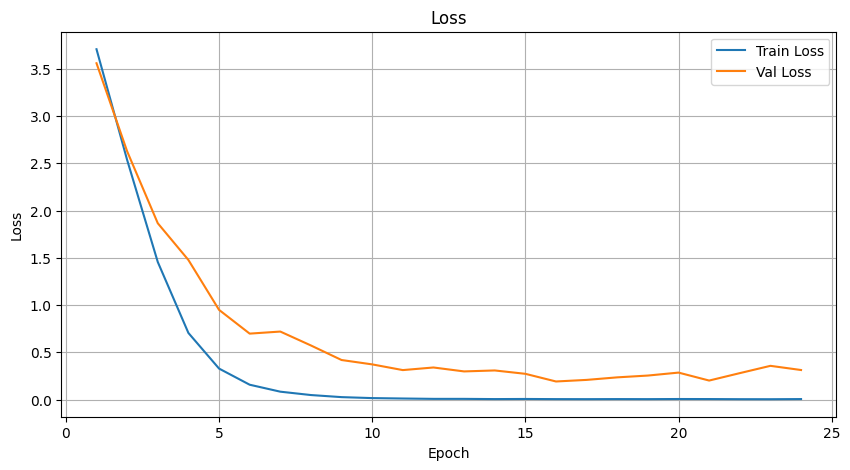

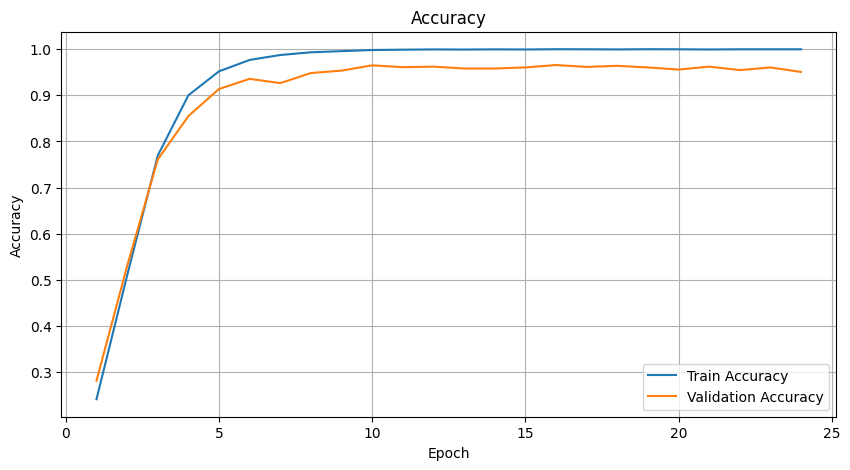

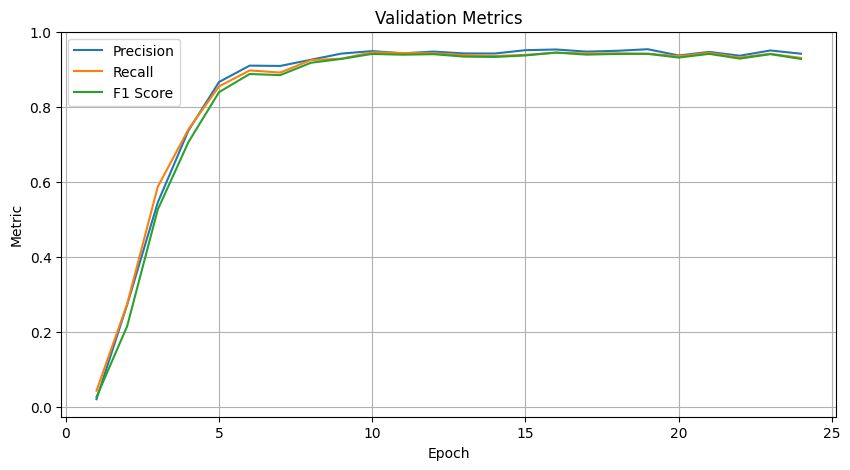

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# HISTORY DATAFRAME
# ============================================================

# history_df = pd.DataFrame(history)

print(history_df.head())

# ============================================================
# LOSS
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history_df['epoch'],
    history_df['train_loss'],
    label='Train Loss'
)

plt.plot(
    history_df['epoch'],
    history_df['val_loss'],
    label='Val Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title('Loss')

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# ACCURACY
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history_df['epoch'],
    history_df['train_acc'],
    label='Train Accuracy'
)

plt.plot(
    history_df['epoch'],
    history_df['val_acc'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.title('Accuracy')

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# PRECISION / RECALL / F1
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history_df['epoch'],
    history_df['precision'],
    label='Precision'
)

plt.plot(
    history_df['epoch'],
    history_df['recall'],
    label='Recall'
)

plt.plot(
    history_df['epoch'],
    history_df['f1'],
    label='F1 Score'
)

plt.xlabel('Epoch')
plt.ylabel('Metric')

plt.title('Validation Metrics')

plt.legend()

plt.grid(True)

plt.show()

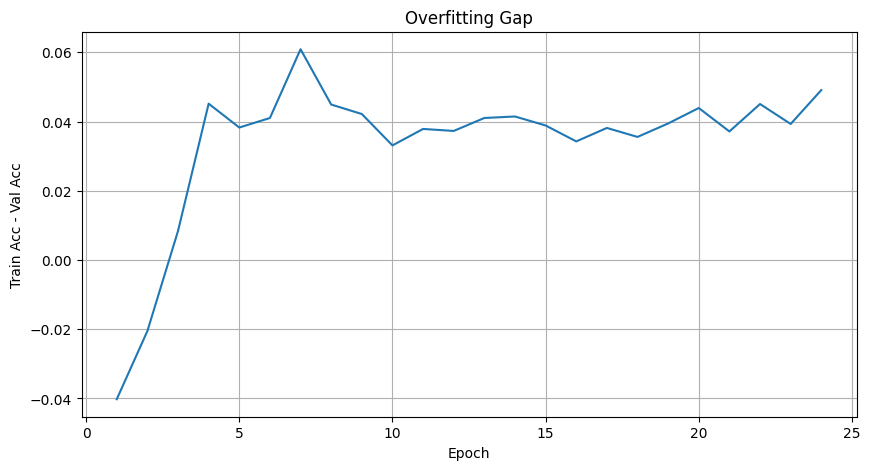

In [ ]:
plt.figure(figsize=(10,5))

gap = (
    history_df['train_acc']
    - history_df['val_acc']
)

plt.plot(
    history_df['epoch'],
    gap
)

plt.xlabel('Epoch')
plt.ylabel('Train Acc - Val Acc')
plt.title('Overfitting Gap')
plt.grid(True)

plt.show()

MLP-классификатор

In [ ]:
# ============================================================
# MLP CLASSIFIER
# ============================================================

class MLPClassifier(nn.Module):

    def __init__(

        self,

        input_dim,

        num_classes
    ):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(
                input_dim,
                2048
            ),

            nn.LayerNorm(2048),

            nn.GELU(),

            nn.Dropout(0.3),

            nn.Linear(
                2048,
                1024
            ),

            nn.LayerNorm(1024),

            nn.GELU(),

            nn.Dropout(0.3),

            nn.Linear(
                1024,
                512
            ),

            nn.LayerNorm(512),

            nn.GELU(),

            nn.Dropout(0.3),

            nn.Linear(
                512,
                num_classes
            )
        )

    def forward(self, x):

        return self.net(x)

In [ ]:
# ============================================================
# RESNET + MLP
# ============================================================

class ResNetMLP(nn.Module):

    def __init__(

        self,

        num_classes=102
    ):

        super().__init__()

        self.backbone = timm.create_model(

            'resnet50',

            pretrained=True,

            num_classes=0,

            global_pool='avg'
        )

        in_features = self.backbone.num_features

        self.classifier = MLPClassifier(

            in_features,

            num_classes
        )

    def forward(self, x):

        x = self.backbone(x)

        x = self.classifier(x)

        return x

In [ ]:
model_name = 'resnet50_mlp'

model = ResNetMLP(

    num_classes=NUM_CLASSES

).to(DEVICE)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

In [ ]:
# ============================================================
# MODEL NAME
# ============================================================

SAVE_DIR = "/content/drive/MyDrive/VKR additional experiments/mlp_variant"
os.makedirs(SAVE_DIR, exist_ok=True)

print("SAVE DIR:", SAVE_DIR)

model_name = 'resnet50_mlp'

best_checkpoint_path = os.path.join(

    SAVE_DIR,

    f'{model_name}_best.pth'
)

last_checkpoint_path = os.path.join(

    SAVE_DIR,

    f'{model_name}_last.pth'
)

SAVE DIR: /content/drive/MyDrive/VKR additional experiments/mlp_variant


In [ ]:
# ============================================================
# MODEL
# ============================================================

model = ResNetMLP(

    num_classes=NUM_CLASSES

).to(DEVICE)

In [ ]:
# ============================================================
# LOSS
# ============================================================

criterion = nn.CrossEntropyLoss()

# ============================================================
# OPTIMIZER
# ============================================================

optimizer = optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=1e-4
)

# ============================================================
# SCHEDULER
# ============================================================

scheduler = optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=NUM_EPOCHS
)

In [ ]:
# ============================================================
# LOSS / OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(

    model.parameters(),

    lr=LR,

    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=NUM_EPOCHS
)

# ============================================================
# EARLY STOPPING
# ============================================================

class EarlyStopping:

    def __init__(

        self,

        patience=8,

        min_delta=1e-4
    ):

        self.patience = patience

        self.min_delta = min_delta

        self.best_loss = np.inf

        self.counter = 0

        self.stop = False

    def __call__(self, val_loss):

        if val_loss < self.best_loss - self.min_delta:

            self.best_loss = val_loss

            self.counter = 0

        else:

            self.counter += 1

            print(
                f'EarlyStopping: '
                f'{self.counter}/{self.patience}'
            )

            if self.counter >= self.patience:

                self.stop = True

early_stopping = EarlyStopping()

# ============================================================
# EVALUATE
# ============================================================

@torch.no_grad()
def evaluate(model, loader, criterion):

    model.eval()

    losses = []

    preds_all = []

    targets_all = []

    for images, targets in loader:

        images = images.to(DEVICE)

        targets = targets.to(DEVICE)

        outputs = model(images)

        loss = criterion(outputs, targets)

        preds = outputs.argmax(dim=1)

        losses.append(loss.item())

        preds_all.extend(
            preds.cpu().numpy()
        )

        targets_all.extend(
            targets.cpu().numpy()
        )

    return {

        'loss': np.mean(losses),

        'accuracy': accuracy_score(
            targets_all,
            preds_all
        ),

        'precision': precision_score(
            targets_all,
            preds_all,
            average='macro',
            zero_division=0
        ),

        'recall': recall_score(
            targets_all,
            preds_all,
            average='macro',
            zero_division=0
        ),

        'f1': f1_score(
            targets_all,
            preds_all,
            average='macro',
            zero_division=0
        )
    }

# ============================================================
# RESUME
# ============================================================

history = []

best_acc = 0

start_epoch = 0

if os.path.exists(last_checkpoint_path):

    checkpoint = torch.load(

        last_checkpoint_path,

        map_location=DEVICE,

        weights_only=False
    )

    model.load_state_dict(
        checkpoint['model_state_dict']
    )

    optimizer.load_state_dict(
        checkpoint['optimizer_state_dict']
    )

    scheduler.load_state_dict(
        checkpoint['scheduler_state_dict']
    )

    best_acc = checkpoint['best_acc']

    history = checkpoint['history']

    start_epoch = checkpoint['epoch'] + 1

    early_stopping.counter = checkpoint.get(
        'early_stopping_counter',
        0
    )

    early_stopping.best_loss = checkpoint.get(
        'early_stopping_best_loss',
        np.inf
    )

    print('=' * 50)

    print('CHECKPOINT LOADED')

    print(f'START EPOCH: {start_epoch}')

    print(f'BEST ACC: {best_acc:.4f}')

    print('=' * 50)

# ============================================================
# AMP
# ============================================================

scaler = torch.amp.GradScaler(

    'cuda',

    enabled=torch.cuda.is_available()
)

# ============================================================
# TRAIN LOOP
# ============================================================

for epoch in range(start_epoch, NUM_EPOCHS):

    model.train()

    train_losses = []

    train_preds = []

    train_targets = []

    loop = tqdm(train_loader)

    for images, targets in loop:

        images = images.to(DEVICE)

        targets = targets.to(DEVICE)

        optimizer.zero_grad()

        with torch.amp.autocast(

            device_type='cuda',

            enabled=torch.cuda.is_available()
        ):

            outputs = model(images)

            loss = criterion(outputs, targets)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            1.0
        )

        scaler.step(optimizer)

        scaler.update()

        train_losses.append(loss.item())

        preds = outputs.argmax(dim=1)

        train_preds.extend(
            preds.detach().cpu().numpy()
        )

        train_targets.extend(
            targets.detach().cpu().numpy()
        )

        loop.set_description(
            f'Epoch {epoch+1}'
        )

        loop.set_postfix(
            loss=loss.item()
        )

    scheduler.step()

    train_loss = np.mean(train_losses)

    train_acc = accuracy_score(

        train_targets,

        train_preds
    )

    val_metrics = evaluate(

        model,

        val_loader,

        criterion
    )

    result = {

        'epoch': epoch + 1,

        'train_loss': float(train_loss),

        'val_loss': float(
            val_metrics['loss']
        ),

        'train_acc': float(train_acc),

        'val_acc': float(
            val_metrics['accuracy']
        ),

        'precision': float(
            val_metrics['precision']
        ),

        'recall': float(
            val_metrics['recall']
        ),

        'f1': float(
            val_metrics['f1']
        )
    }

    history.append(result)

    print('\n')

    print(result)

    # ========================================================
    # SAVE LAST
    # ========================================================

    torch.save({

        'epoch': epoch,

        'model_state_dict': model.state_dict(),

        'optimizer_state_dict': optimizer.state_dict(),

        'scheduler_state_dict': scheduler.state_dict(),

        'best_acc': best_acc,

        'history': history,

        'early_stopping_counter':
            early_stopping.counter,

        'early_stopping_best_loss':
            early_stopping.best_loss

    },

    last_checkpoint_path)

    print('LAST CHECKPOINT SAVED')

    # ========================================================
    # SAVE BEST
    # ========================================================

    if val_metrics['accuracy'] > best_acc:

        best_acc = val_metrics['accuracy']

        torch.save({

            'epoch': epoch,

            'model_state_dict': model.state_dict(),

            'optimizer_state_dict': optimizer.state_dict(),

            'scheduler_state_dict': scheduler.state_dict(),

            'best_acc': best_acc,

            'history': history,

            'early_stopping_counter':
                early_stopping.counter,

            'early_stopping_best_loss':
                early_stopping.best_loss

        },

        best_checkpoint_path)

        print(
            f'BEST CHECKPOINT SAVED: '
            f'{best_acc:.4f}'
        )

    # ========================================================
    # EARLY STOPPING
    # ========================================================

    early_stopping(
        val_metrics['loss']
    )

    if early_stopping.stop:

        print('\nEARLY STOPPING')

        break

# ============================================================
# SAVE HISTORY CSV
# ============================================================

history_df = pd.DataFrame(history)

history_df.to_csv(

    os.path.join(

        SAVE_DIR,

        f'{model_name}_history.csv'
    ),

    index=False
)

print('\nTRAINING FINISHED')

Epoch 1: 100%|██████████| 217/217 [00:48<00:00,  4.46it/s, loss=0.272]




{'epoch': 1, 'train_loss': 0.5243388076531722, 'val_loss': 0.21085966459729455, 'train_acc': 0.9282524131969457, 'val_acc': 0.9475806451612904, 'precision': 0.9271972821556711, 'recall': 0.9188098063395204, 'f1': 0.9095886660922173}
LAST CHECKPOINT SAVED
BEST CHECKPOINT SAVED: 0.9476


Epoch 2: 100%|██████████| 217/217 [00:50<00:00,  4.31it/s, loss=0.0536]




{'epoch': 2, 'train_loss': 0.15687210274182156, 'val_loss': 0.1346613209440627, 'train_acc': 0.9727704941651059, 'val_acc': 0.9642857142857143, 'precision': 0.9479404380617931, 'recall': 0.9474356121110504, 'f1': 0.9419495407157634}
LAST CHECKPOINT SAVED
BEST CHECKPOINT SAVED: 0.9643


Epoch 3: 100%|██████████| 217/217 [01:05<00:00,  3.31it/s, loss=0.0245]


...



{'epoch': 9, 'train_loss': 0.005221369276080744, 'val_loss': 0.14842406561206603, 'train_acc': 0.9991355712433367, 'val_acc': 0.9671658986175116, 'precision': 0.9497532652210783, 'recall': 0.9490915745693939, 'f1': 0.9466455944478941}
LAST CHECKPOINT SAVED
EarlyStopping: 6/8


Epoch 10: 100%|██████████| 217/217 [00:55<00:00,  3.89it/s, loss=0.00433]




{'epoch': 10, 'train_loss': 0.0033322008914627513, 'val_loss': 0.14383838384422812, 'train_acc': 0.9992796427027806, 'val_acc': 0.9735023041474654, 'precision': 0.9592736781033833, 'recall': 0.9599033231650678, 'f1': 0.9571934140206987}
LAST CHECKPOINT SAVED
BEST CHECKPOINT SAVED: 0.9735
EarlyStopping: 7/8


Epoch 11: 100%|██████████| 217/217 [01:04<00:00,  3.34it/s, loss=0.00245]




{'epoch': 11, 'train_loss': 0.007755818755327282, 'val_loss': 0.14132133843483063, 'train_acc': 0.9981270710272295, 'val_acc': 0.9723502304147466, 'precision': 0.9583160823438072, 'recall': 0.9573841426755904, 'f1': 0.9550907028052857}
LAST CHECKPOINT SAVED
EarlyStopping: 8/8

EARLY STOPPING

TRAINING FINISHED


In [ ]:
history_df = pd.read_csv(
    os.path.join(
        SAVE_DIR,
        f'{model_name}_history.csv'
    )
)

print(history_df.tail())

    epoch  train_loss  val_loss  train_acc   val_acc  precision    recall  \
6       7    0.006730  0.139002   0.999424  0.968318   0.953329  0.952361   
7       8    0.005342  0.135110   0.999424  0.970046   0.954468  0.954066   
8       9    0.005221  0.148424   0.999136  0.967166   0.949753  0.949092   
9      10    0.003332  0.143838   0.999280  0.973502   0.959274  0.959903   
10     11    0.007756  0.141321   0.998127  0.972350   0.958316  0.957384   

          f1  
6   0.949105  
7   0.951958  
8   0.946646  
9   0.957193  
10  0.955091  


   epoch  train_loss  val_loss  train_acc   val_acc  precision    recall  \
0      1    0.524339  0.210860   0.928252  0.947581   0.927197  0.918810   
1      2    0.156872  0.134661   0.972770  0.964286   0.947940  0.947436   
2      3    0.055757  0.119057   0.990059  0.967742   0.953428  0.953450   
3      4    0.027717  0.128827   0.993805  0.971774   0.957213  0.961575   
4      5    0.016906  0.134200   0.996542  0.967166   0.949766  0.950696   

         f1  
0  0.909589  
1  0.941950  
2  0.951033  
3  0.956253  
4  0.946466  


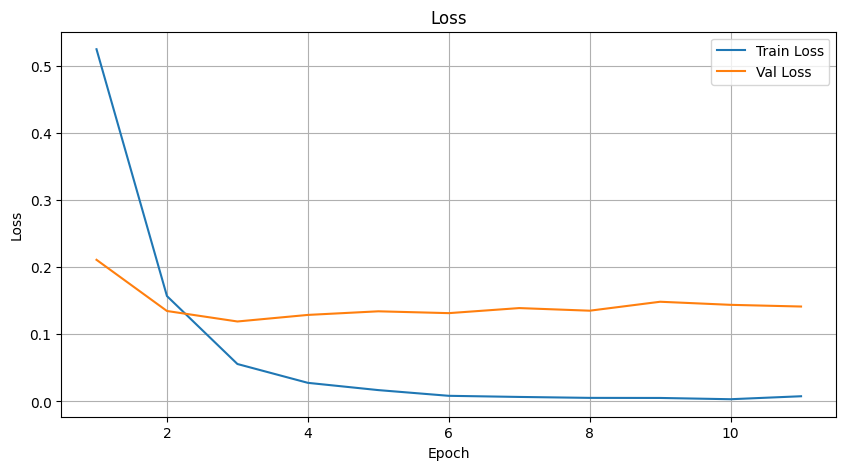

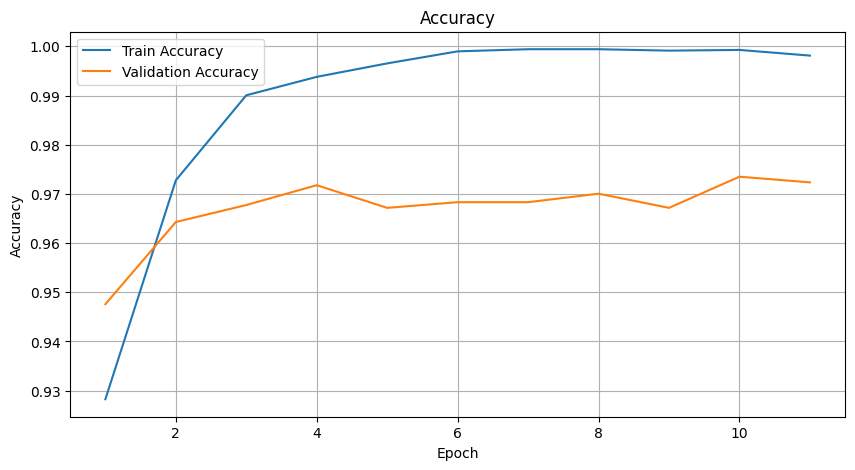

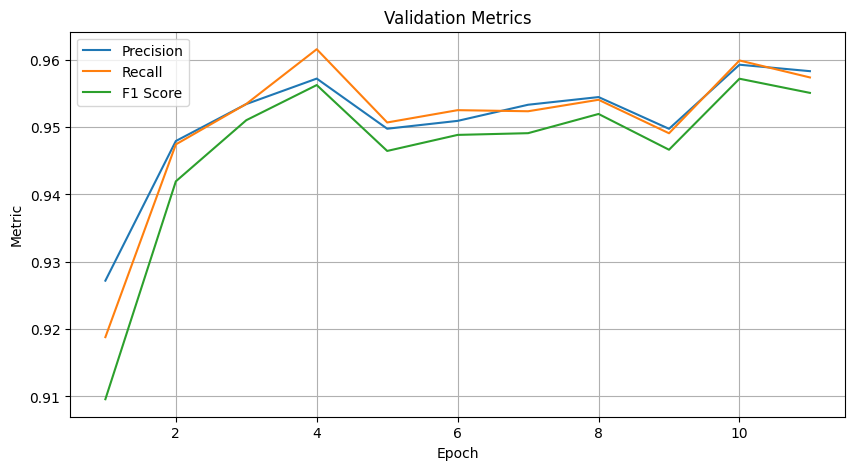

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# HISTORY DATAFRAME
# ============================================================

# history_df = pd.DataFrame(history)

print(history_df.head())

# ============================================================
# LOSS
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history_df['epoch'],
    history_df['train_loss'],
    label='Train Loss'
)

plt.plot(
    history_df['epoch'],
    history_df['val_loss'],
    label='Val Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title('Loss')

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# ACCURACY
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history_df['epoch'],
    history_df['train_acc'],
    label='Train Accuracy'
)

plt.plot(
    history_df['epoch'],
    history_df['val_acc'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.title('Accuracy')

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# PRECISION / RECALL / F1
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history_df['epoch'],
    history_df['precision'],
    label='Precision'
)

plt.plot(
    history_df['epoch'],
    history_df['recall'],
    label='Recall'
)

plt.plot(
    history_df['epoch'],
    history_df['f1'],
    label='F1 Score'
)

plt.xlabel('Epoch')
plt.ylabel('Metric')

plt.title('Validation Metrics')

plt.legend()

plt.grid(True)

plt.show()

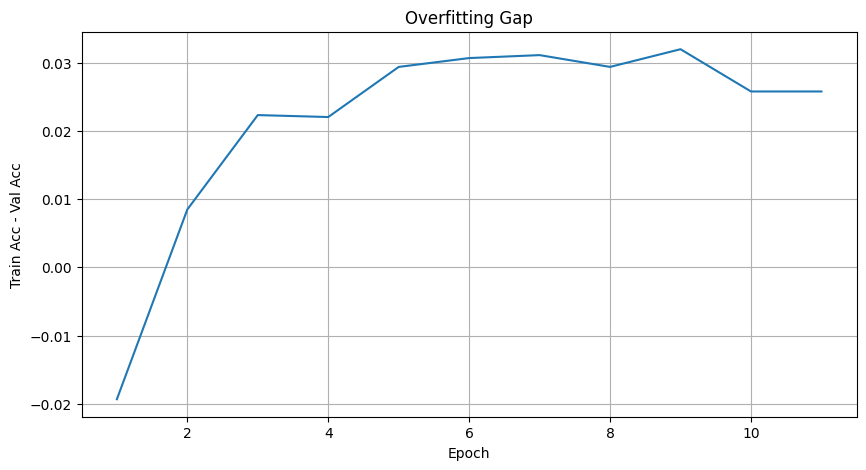

In [ ]:
plt.figure(figsize=(10,5))

gap = (
    history_df['train_acc']
    - history_df['val_acc']
)

plt.plot(
    history_df['epoch'],
    gap
)

plt.xlabel('Epoch')
plt.ylabel('Train Acc - Val Acc')
plt.title('Overfitting Gap')
plt.grid(True)

plt.show()